## Data import — load the two source datasets plus py-packages

This cell loads the FR (data.gouv.fr / UTAC) and EU (EEA) df and renames the
French column headers to English and suitable names.

After this cell, `df` and `df_eu` are in memory and most relevant packages available.

In [1]:
# Import Packages

import numpy as np
import pandas as pd
from sklearn import model_selection, preprocessing
from sklearn.model_selection import (cross_val_predict, cross_val_score,
                                     cross_validate, train_test_split)
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [ ]:
# Define file locations

file1_path = "co2/work/cl_JUIN_2013-complet3.csv"     # FR - data.gouv.fr / UTAC
file2_path = "co2/work/CO2_passenger_cars_v8.csv"     # EU - EEA, all member states
file3_path = "co2/work/CO2_passenger_cars_v8_FR.csv"  # EU - pre-filtered to MS == 'FR'

In [3]:
# Import database: df_eu

# One-off preparation step (kept for provenance, re-run only if file3 is missing):
# df_eu = pd.read_csv(file2_path, sep=None, engine='python')
# df_eu = df_eu[df_eu['MS'] == 'FR'].copy()   # Filter df_eu for France
# df_eu.to_csv(file3_path, index=False)

df_eu = pd.read_csv(file3_path)

print(df_eu.nunique())
display(df_eu.sample(12))

Unnamed: 0    32332
id            32332
MS                1
MP               12
Mh               69
MAN              68
MMS              75
TAN            2369
T               433
Va             3209
Ve             5562
Mk               70
Cn              679
Ct                2
r              1069
e (g/km)        245
m (kg)         1304
w (mm)          275
at1 (mm)        240
at2 (mm)        245
Ft               13
Fm                3
ec (cm3)        169
ep (KW)         223
z (Wh/km)        17
IT                0
Er (g/km)         0
dtype: int64


,Unnamed: 0,id,MS,MP,Mh,MAN,MMS,TAN,T,Va,...,w (mm),at1 (mm),at2 (mm),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Er (g/km)
9592,182703,182704,FR,DAIMLER AG,DAIMLER AG,DAIMLER AG,DAIMLER AG,e1*2001/116*0480*13,204X,H7S2M1,...,2755.0,1585.0,1599.0,Diesel,M,2143.0,125.0,NaN,NaN,NaN
15227,188338,188339,FR,FORD-WERKE GMBH,FORD WERKE GMBH,FORD-WERKE GMBH,FORD WERKE GMBH,e11*2007/46*0676*00,FAC,CYFF1EBA,...,2933.0,1756.0,1740.0,Diesel,M,2198.0,92.0,NaN,NaN,NaN
31587,204698,204699,FR,VW GROUP PC,VOLKSWAGEN,VOLKSWAGEN AG,VOLKSWAGEN AG,e13*2007/46*1167*07,AA,ABCHYB,...,2407.0,1428.0,1424.0,Petrol,M,999.0,55.0,NaN,NaN,NaN
22839,195950,195951,FR,GENERAL MOTORS,OPEL,ADAM OPEL AG,ADAM OPEL AG,e1*2001/116*0379*22,S-D,UR11,...,2311.0,1472.0,1464.0,Petrol,M,1398.0,74.0,NaN,NaN,NaN
4922,178033,178034,FR,NaN,AUTOMOBILES PEUGEOT,AUTOMOBILES PEUGEOT,AUTOMOBILES PEUGEOT,e2*98/14*0253*26,E,BRHD,...,2823.0,1570.0,1548.0,Diesel,M,1997.0,100.0,NaN,NaN,NaN
31152,204263,204264,FR,VW GROUP PC,VOLKSWAGEN,VOLKSWAGEN AG,VOLKSWAGEN AG,e1*2001/116*0450*16,5N,ACCFFBX1,...,2605.0,1575.0,1577.0,Diesel,M,1968.0,103.0,NaN,NaN,NaN
20665,193776,193777,FR,NaN,NISSAN,NISSAN INTERNATIONAL SA,NISSAN INTERNATIONAL SA,e11*2001/116*0295*25,J10,K,...,2630.0,1540.0,1545.0,Diesel,M,1598.0,96.0,NaN,NaN,NaN
1233,174344,174345,FR,VW GROUP PC,AUDI AG,AUDI AG,AUDI AG,e1*2001/116*0430*29,B8,SCLABF1,...,2817.0,1581.0,1570.0,Diesel,M,2967.0,150.0,NaN,NaN,NaN
9022,182133,182134,FR,DAIMLER AG,DAIMLER AG,DAIMLER AG,DAIMLER AG,e1*2001/116*0502*13,207,L3S2M0,...,2760.0,1552.0,1558.0,Diesel,M,2143.0,125.0,NaN,NaN,NaN
20478,193589,193590,FR,NaN,NISSAN,NISSAN INTERNATIONAL SA,NISSAN INTERNATIONAL SA,e11*2001/116*0295*23,J10,M,...,2630.0,1540.0,1545.0,Diesel,M,1598.0,96.0,NaN,NaN,NaN


In [ ]:
# Import and loads database df (French gvt catalogue)

# integrate data download from https://www.data.gouv.fr
df = pd.read_csv(file1_path, encoding="latin1", sep=";")  # fr var

# rename var
rename_map = {
    'Marque': 'brand',
    'Modèle dossier': 'model_file',
    'Modèle UTAC': 'model_utac',
    'Désignation commerciale': 'commercial_name',
    'CNIT': 'ntic',  # National Type Identification Code
    'Type Variante Version (TVV)': 'tvv',
    'Carburant': 'fuel',
    'Hybride': 'hybrid',
    'Puissance administrative': 'power_admin',
    'Puissance maximale (kW)': 'power_max_kw',
    'Boîte de vitesse': 'transmission',
    'Consommation urbaine (l/100km)': 'cons_urb_l100km',  # urban consumption
    'Consommation extra-urbaine (l/100km)': 'cons_extraurb_l100km',
    'Consommation mixte (l/100km)': 'cons_mix_l100km',
    'CO2 (g/km)': 'co2_g_km',
    'CO type I (g/km)': 'co_g_km',
    'HC (g/km)': 'hc_g_km',
    'NOX (g/km)': 'nox_g_km',
    'HC+NOX (g/km)': 'hc_nox_g_km',
    'Particules (g/km)': 'pm_g_km',  # Particulate matter (g per km)
    'masse vide euro min (kg)': 'kerb_weight_min_kg',
    'masse vide euro max (kg)': 'mkerb_weight_max_kg',
    'Champ V9': 'champ_v9',
    'Date de mise à jour': 'date_maj',
    'Carrosserie': 'body_type',
    'gamme': 'segment',
}

df = df.rename(columns=rename_map)

# Get an overview of the data
display(df.sample(10))

# how many uniques?
display(df.nunique())

# print("check Missings: ", df.isna().sum())

print(df["brand"].value_counts()) # brand overview
display(df[df["ntic"] == "M10FATVP001M592"]) # view doublettes

,brand,model_file,model_utac,commercial_name,ntic,tvv,fuel,hybrid,power_admin,power_max_kw,...,hc_g_km,nox_g_km,hc_nox_g_km,pm_g_km,kerb_weight_min_kg,mkerb_weight_max_kg,champ_v9,date_maj,body_type,segment
23615,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.0 CDI,M10MCDVP024P227,639/2LAA71280N1M3J2S38,GO,non,9,100.0,...,NaN,0.226,0.248,0.001,2025,2075,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER
16524,MERCEDES-BENZ,SPRINTER,SPRINTER,SPRINTER COMBI 213 CDI - 37,M10MCDVPF17Z968,906AC35KNMC1349NMEB25TA9,GO,non,9,95.0,...,NaN,0.221,0.287,0.000,2076,2185,715/2007*566/2011EURO5,juin-13,MINIBUS,MOY-INFER
17954,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,M10MCDVP602S877,639/2LAA31280N1A2D2U38,GO,non,11,120.0,...,NaN,0.190,0.201,0.001,2186,2275,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER
17167,MERCEDES-BENZ,SPRINTER,SPRINTER,SPRINTER COMBI 316 CDI - 37,M10MCDVPF18R535,906AC35KNMD1349EMEC23WB9,GO,non,10,120.0,...,0.008,1.843,NaN,0.004,2586,2849,2005/55*2008/74EEV,juin-13,MINIBUS,MOY-INFER
13882,MERCEDES-BENZ,SPRINTER,SPRINTER,SPRINTER COMBI 213 CDI - 32,M10MCDVPF15R731,906AC35KMMC1349NNEC25WB9,GO,non,9,95.0,...,NaN,0.230,0.263,0.000,2586,2705,715/2007*566/2011EURO5,juin-13,MINIBUS,MOY-INFER
39091,MERCEDES-BENZ,VITO,VITO,COMBI 113 CDI,M10MCDVP376V438,639/2KAA71305N2M3G1T29,GO,non,9,100.0,...,NaN,0.226,0.248,0.001,2076,2185,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-INFER
11513,MERCEDES-BENZ,SPRINTER,SPRINTER,SPRINTER COMBI 213 CDI - 32,M10MCDVPF13U737,906AC35KHMC1349NMCC2GWA9,GO,non,9,95.0,...,0.008,1.843,NaN,0.004,2586,2849,2005/55*2008/74EURO5,juin-13,MINIBUS,MOY-INFER
36562,MERCEDES-BENZ,VITO,VITO,COMBI 116 CDI,M10MCDVPG12K436,639/2KAA31320E3M3E2U38,GO,non,10,120.0,...,NaN,0.197,0.216,0.000,2186,2355,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-INFER
16133,MERCEDES-BENZ,SPRINTER,SPRINTER,SPRINTER COMBI 213 CDI - 37,M10MCDVPF172644,906AC35KNMC1280NMFB25SB7,GO,non,9,95.0,...,NaN,0.275,0.287,0.000,2052,2075,715/2007*566/2011EURO5,juin-13,MINIBUS,MOY-INFER
38355,MERCEDES-BENZ,VITO,VITO,COMBI 113 CDI,M10MCDVPG12W545,639/2KAA71280N3M3J1U28,GO,non,9,100.0,...,NaN,0.197,0.216,0.000,2186,2275,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-INFER


brand                      51
model_file                458
model_utac                419
commercial_name          3582
ntic                    44191
tvv                     28781
fuel                       13
hybrid                      2
power_admin                62
power_max_kw              223
transmission               16
cons_urb_l100km           204
cons_extraurb_l100km       91
cons_mix_l100km           135
co2_g_km                  264
co_g_km                   593
hc_g_km                    71
nox_g_km                  219
hc_nox_g_km               180
pm_g_km                    16
kerb_weight_min_kg        859
mkerb_weight_max_kg       937
champ_v9                   13
date_maj                    3
body_type                  10
segment                     7
dtype: int64

brand
MERCEDES-BENZ                38450
VOLKSWAGEN                     900
FIAT                           607
OPEL                           586
BMW                            525
SKODA                          364
FORD                           296
AUDI                           242
CITROEN                        207
MAZDA                          193
LEXUS                          175
MERCEDES AMG                   174
NISSAN                         173
PEUGEOT                        160
RENAULT                        155
TOYOTA                         111
VOLVO                          106
SEAT                           105
ALFA-ROMEO                     103
PORSCHE                         89
MINI                            79
ASTON MARTIN                    78
KIA                             78
JEEP                            74
CHEVROLET                       63
JAGUAR LAND ROVER LIMITED       55
HYUNDAI                         52
SMART                           52
HONDA         

,brand,model_file,model_utac,commercial_name,ntic,tvv,fuel,hybrid,power_admin,power_max_kw,...,hc_g_km,nox_g_km,hc_nox_g_km,pm_g_km,kerb_weight_min_kg,mkerb_weight_max_kg,champ_v9,date_maj,body_type,segment
1404,FIAT,500,500,500 1.2 8V,M10FATVP001M592,312AXA1A00R,ES/GP,non,4,51.0,...,0.026,0.016,NaN,NaN,940,940,715/2007*692/2008EURO5,juin-13,BERLINE,ECONOMIQUE
1405,FIAT,500,500,500 1.2 8V,M10FATVP001M592,312AXA1A00R,ES/GP,non,4,51.0,...,0.026,0.016,NaN,NaN,940,940,715/2007*692/2008EURO5,juin-13,BERLINE,ECONOMIQUE
1406,FIAT,500,500,500 1.2 8V,M10FATVP001M592,312AXA1A00R,ES/GP,non,4,51.0,...,0.026,0.016,NaN,NaN,940,940,715/2007*692/2008EURO5,juin-13,BERLINE,ECONOMIQUE
1407,FIAT,500,500,500 1.2 8V,M10FATVP001M592,312AXA1A00R,ES/GP,non,4,51.0,...,0.026,0.016,NaN,NaN,940,940,715/2007*692/2008EURO5,juin-13,BERLINE,ECONOMIQUE
1408,FIAT,500,500,500 1.2 8V,M10FATVP001M592,312AXA1A00R,ES/GP,non,4,51.0,...,0.026,0.016,NaN,NaN,940,940,715/2007*692/2008EURO5,juin-13,BERLINE,ECONOMIQUE
1409,FIAT,500,500,500 1.2 8V,M10FATVP001M592,312AXA1A00R,ES/GP,non,4,51.0,...,0.026,0.016,NaN,NaN,940,940,715/2007*692/2008EURO5,juin-13,BERLINE,ECONOMIQUE
1410,FIAT,500,500,500 1.2 8V,M10FATVP001M592,312AXA1A00R,ES/GP,non,4,51.0,...,0.026,0.016,NaN,NaN,940,940,715/2007*692/2008EURO5,juin-13,BERLINE,ECONOMIQUE
1411,FIAT,500,500,500 1.2 8V,M10FATVP001M592,312AXA1A00R,ES/GP,non,4,51.0,...,0.026,0.016,NaN,NaN,940,940,715/2007*692/2008EURO5,juin-13,BERLINE,ECONOMIQUE
1412,FIAT,500,500,500 1.2 8V,M10FATVP001M592,312AXA1A00R,GP/ES,non,4,51.0,...,0.032,0.038,NaN,NaN,940,940,715/2007*692/2008EURO5,juin-13,BERLINE,ECONOMIQUE
1413,FIAT,500,500,500 1.2 8V,M10FATVP001M592,312AXA1A00R,GP/ES,non,4,51.0,...,0.032,0.038,NaN,NaN,940,940,715/2007*692/2008EURO5,juin-13,BERLINE,ECONOMIQUE


## Configuration, Tools, Rules ...

... All in one place: A single config block for organising and preparing the pipeline.

In [ ]:
# collection of tools and "rules" in one place

import os
import re
import numpy as np
import pandas as pd

# configuration for processing below
CFG = {
    # This part starts before working with the datasets |FR - EU|
    "TOL_KW": 3,
    "TOL_CO2": 10,
    "TOL_KG": 100,
    # tv_comp length-inference (D1): share of identical string lengths required inside a group
    "TV_LEN_SHARE": 0.90,
    # tv_comp slice: tvv_clean = T + Va + Ve, so T+Va is a PREFIX
    "TV_SLICE_FROM": 0,
    # fuzzy matching (Step 4)
    "FUZZY_MIN": 80.0,
    # Step 4 gate: T shorter than this is not a discriminating criterion
    # EEA source is 2 characters.
    "MIN_T_LEN": 3,
    # Fan-out ceiling: DELIBERATELY UNLIMITED (0).
    # solved properly in deduplication part by collapsing each FR config back to 1 row
    # while summing its volume.
    "MAX_FANOUT": 0,
    # fan-out policy: Step 3 attaches right_only rows to already-matched FR rows and
    # therefore must duplicate them. Steps 2 and 4 consume unmatched pools and stay 1:1.
    "FANOUT": {"step2": False, "step3": True, "step4": False},
    # audit scope: partial-duplicate detection is combinatorial, so it runs on a subset
    "AUDIT_COLS_FR": ["tvv", "brand", "model_file", "commercial_name", "fuel",
                      "power_max_kw", "co2_g_km", "mkerb_weight_max_kg"],
    "AUDIT_COLS_EU": ["T", "Va", "Ve", "Mk", "Cn", "Ft", "ep (KW)", "e (g/km)", "m (kg)"],
    "AUDIT_MAX_DEGREE": 4,
    # safety valve: abort a blocking join that would build an unreasonable candidate frame
    # for the execution-cell: selective merge for structurally under-matched brands
    "SELECTIVE_THRESHOLD": 0.70,     # brands below this weighted rate qualify
    "SELECTIVE_MIN_MODEL_LEVEL": 1,  # 2 = model strings identical, 1 = token subset
    "MAX_CANDIDATES": 20_000_000,
    "RTOL": 1e-5,
    # fuel grouping: the notebook folded E85 into 'Petrol'. E85 consumes ~30% 
    # more volume per km at a lower carbon factor and is in a different tax bracket,
    # so merging it created some error into the largest fuel class in prev. version. 
    # So it is kept separate by default; flip to True to reproduce the ipynb's grouping.
    "E85_AS_PETROL": False,
}

# fuzzy backend as a solution when meeting errors in running the script:
try:
    from rapidfuzz import fuzz as _rf_fuzz
    _FUZZ_BACKEND = "rapidfuzz"

    def partial_ratio(a: str, b: str) -> float:
        return _rf_fuzz.partial_ratio(a, b)
except ImportError:  # ... no cover
    from difflib import SequenceMatcher
    _FUZZ_BACKEND = "difflib"

    def partial_ratio(a: str, b: str) -> float:
        '''Best sliding-window similarity of `a` inside `b`, scaled to 0-100.'''
        if not a or not b:
            return 0.0
        if a in b:
            return 100.0
        if len(b) < len(a):
            return 0.0
        best = 0.0
        for i in range(len(b) - len(a) + 1):
            best = max(best, SequenceMatcher(None, a, b[i:i + len(a)]).ratio())
            if best >= 0.99:
                break
        return best * 100.0

# Some string / numeric helpers
def clean_key(s: pd.Series) -> pd.Series:
    '''Uppercase and strip every non-alphanumeric character. Missing -> empty string.'''
    # fix vs 1st vers: .str.upper() must run before the [^A-Z0-9] filter, otherwise:
    # every lowercase letter is deleted instead of normalised. before: inconsistently
    return (s.fillna('').astype(str).str.upper()
             .str.replace(r'[^A-Z0-9]', '', regex=True))


def to_int(s: pd.Series) -> pd.Series:
    '''Round to nullable Int64 avoiding NaN silently becoming a float.'''
    return pd.to_numeric(s, errors='coerce').round().astype('Int64')


# translate/transfer fuelcodes:
FUEL_MAP_FR = {
    'ES': 'PETROL', 'GO': 'DIESEL', 'EH': 'HYBRID_PETROL', 'GH': 'HYBRID_DIESEL',
    'EL': 'ELECTRIC', 'EE': 'E85', 'FE': 'E85', 'GN': 'NG', 'GL': 'LPG',
    'ES/GP': 'LPG', 'GP/ES': 'LPG', 'ES/GN': 'NG', 'GN/ES': 'NG',
}
# fuel_comp must comply with FR definitions of fuels - now back to FR original codes:
FUEL_STD_TO_FR = {
    'PETROL': 'ES', 'DIESEL': 'GO', 'HYBRID_PETROL': 'EH', 'HYBRID_DIESEL': 'GH',
    'ELECTRIC': 'EL', 'E85': 'FE', 'NG': 'GN', 'LPG': 'GL', 'HYDROGEN': 'H2',
}
FUEL_MAP_EU = {
    'PETROL': 'PETROL', 'DIESEL': 'DIESEL', 'ELECTRIC': 'ELECTRIC',
    'PETROL-ELECTRIC': 'HYBRID_PETROL', 'DIESEL-ELECTRIC': 'HYBRID_DIESEL',
    'LPG': 'LPG', 'E85': 'E85', 'NG-BIOMETHANE': 'NG', 'HYDROGEN': 'HYDROGEN',
}


def map_fuel(s: pd.Series, mapping: dict, label: str) -> pd.Series:
    '''a registry-specific fuel field onto the shared mapping (and show leftovers).'''
    key = s.astype(str).str.upper().str.strip()
    out = key.map(mapping).astype('string')
    unmapped = key[out.isna() & s.notna()].value_counts()
    if not unmapped.empty:
        print(f"[FUEL] {label}: {int(unmapped.sum()):,} rows with unmapped fuel codes -> "
              f"{unmapped.head(8).to_dict()}")
    return out

# Harmonize brand names
BRAND_MAPPING = {
    "MERCEDES BENZ": "MERCEDES-BENZ", "MERCEDES AMG": "MERCEDES-BENZ",
    "ALFA ROMEO": "ALFA-ROMEO", "ROLLS ROYCE": "ROLLS-ROYCE",
    "JAGUAR CARS LIMITED": "JAGUAR LAND ROVER", "JAGUAR": "JAGUAR LAND ROVER",
    "JAGUAR LAND ROVER LIMITED": "JAGUAR LAND ROVER", "LAND ROVER": "JAGUAR LAND ROVER",
    "FORD CNG TECHNIK": "FORD", "RENAULT TECH": "RENAULT",
    "BMW I": "BMW", "ABARTH": "FIAT",
}


# a solution found to errors:
# put literal characters into the pattern...
_UNICODE_SPACES = ("\u00a0\u1680\u2000\u2001\u2002\u2003\u2004\u2005\u2006\u2007\u2008"
                   "\u2009\u200a\u202f\u205f\u3000\u2028\u2029")
_WS_PATTERN = "[" + _UNICODE_SPACES + " \t\r\n\f\v]+"

# efforts to create a common brand list over the 2 datasets
def standardize_brand(s: pd.Series) -> pd.Series:
    '''Harmonise brand spelling across both registries into the join group key.'''
    # changed compared to prev version: the original left internal double spaces and non-breaking spaces intact, so
    # "ALFA  ROMEO" never hit the mapping table. Collapse whitespace BEFORE the lookup.
    # `.astype('string')` instead of `.astype(str)`: produces missings before.
    # dtype keeps NA as NA through every step.
    out = (s.astype('string')
            .str.replace(_WS_PATTERN, ' ', regex=True)
            .str.replace("-", " ", regex=False)
            .str.strip().str.upper()
            .str.replace(_WS_PATTERN, ' ', regex=True)
            .replace(BRAND_MAPPING))
    # BUGFIX vs original: the original ran .fillna('') first and then .replace("NAN", 
    # Now "NAN"/"NONE" are kept to solve errors from .astype(str)
    return out.replace({'': pd.NA, 'NAN': pd.NA, 'NONE': pd.NA})

# another solution to a TVV problem found:
def repair_sci_notation(s: pd.Series) -> pd.Series:
    '''
    Undo the spreadsheet corruption "1E11" -> "1.00E+11". 111 `Va` values and 4 `Ve` values in EEA file carrying this artefact. Left uncleaned, clean_key turns them into
    "100E11", which matches nothing.
    '''
    return s.astype(str).str.replace(r'^(\d+)\.0*E\+?(\d+)$', r'\1E\2', regex=True)

# a solution found to deal with trailing zeros in TVV variable.
def strip_trailing_zeros(s: pd.Series) -> pd.Series:
    '''Remove all trailing zeroes; `r'0+$'` already covers the single-zero case.'''
    return s.astype(str).str.replace(r'0+$', '', regex=True)

# a solution found to errors regarding harmonizing models (of brands)
def strip_brand_from_model(text: pd.Series, brand: pd.Series) -> pd.Series:
    '''
    Remove brand and sub-brand tokens from a model string, groupwise instead of row-wise.
    Tokens shorter than 3 characters are never stripped, so codes like "208" survive.
    '''
    base = (text.fillna('').astype(str).str.upper()
                .str.replace(r'[^A-Z0-9\s]', ' ', regex=True)
                .str.replace(r'\s+', ' ', regex=True).str.strip())
    out = base.copy()
    for b, idx in brand.dropna().groupby(brand.dropna()).groups.items():
        tokens = {t for t in re.split(r'[\s\-]+', str(b)) if len(t) >= 3}
        tokens.add(re.sub(r'[^A-Z0-9\s]', '', str(b)).strip())
        tokens = sorted({t for t in tokens if t}, key=len, reverse=True)
        if not tokens:
            continue
        pat = r'\b(?:' + '|'.join(re.escape(t) for t in tokens) + r')\b'
        out.loc[idx] = (out.loc[idx].str.replace(pat, '', regex=True)
                                    .str.replace(r'\s+', ' ', regex=True).str.strip())
    return out.replace('', pd.NA).astype('string')


print(f"Configuration-function loaded. Fuzzy backend: {_FUZZ_BACKEND}")

[v1.0] Config loaded. Fuzzy backend: rapidfuzz


## FR Categorical Recoding: Reducing or Creating Groups for Analysis Purposes

This cell builds `brand_clean`, `fuel_display_name`, `fuel_grp`, `segment_grp`, `segment_ord`,
`body_type_display_name` and `body_type_grp` on the French registry, plus the two raw
normalisation twins `fuel_clean_raw` / `body_clean_raw`.

Why? To find better compositions of categories particularly for modelling.
Some changes were implemented during the process of finding solutions:
1. `.fillna('Other')` no longer hides anything. Every unmapped raw code becommes visible.
2. E85 no longer merged into Petrol (switchable via `CFG['E85_AS_PETROL']`). E85 burns
   ~30% more volume per km than petrol and is registered under a distinct tax treatment; folding
   it into Petrol was contributing a systematic CO2 offset into the largest fuel class.
3. `segment_grp` gains an ordinal twin `segment_ord`. The segment ladder is ordered
   (Economy < Lower-Medium < Upper-Medium < Premium < Luxury), for, e.g., linear models.
4. `segment_grp` gets an explicit `Unknown` level. Before the notebook's bare `.map()` left
   unmapped segments as NaN.

These features are FR-only and in the merged datafile - which we use for modelling. `right_only` rows (EU records with no French counterpart) carry NaN in all of them by definition, but these are not used for modelling.

In [ ]:
# categorical recoding for FR and merged data

FUEL_RAW_MAP = {
    'ES': 'Petrol', 'GO': 'Diesel', 'EH': 'Hybrid Petrol', 'GH': 'Hybrid Diesel',
    'EE': 'E85', 'FE': 'E85', 'EL': 'Electric',
    'ES/GP': 'LPG/Petrol', 'GP/ES': 'LPG/Petrol',
    'ES/GN': 'NG/Petrol', 'GN/ES': 'NG/Petrol',
    'GN': 'Natural Gas', 'GL': 'LPG',
}

FUEL_GROUP_MAP = {
    'LPG/Petrol': 'Gas(-Mix)', 'NG/Petrol': 'Gas(-Mix)',
    'Natural Gas': 'Gas(-Mix)', 'LPG': 'Gas(-Mix)',
    'Electric': 'Electric/Hybrid', 'Hybrid Petrol': 'Electric/Hybrid',
    'Hybrid Diesel': 'Electric/Hybrid',
}

SEGMENT_MAP = {
    'ECONOMIQUE': 'Low/Economy', 'INFERIEURE': 'Low/Economy',
    'MOY-INFER': 'Lower-Medium', 'MOY-INF': 'Lower-Medium',   # source carries both spellings
    'MOY-SUPER': 'Upper-Medium', 'SUPERIEURE': 'Premium', 'LUXE': 'Luxury',
}
SEGMENT_ORDER = ['Low/Economy', 'Lower-Medium', 'Upper-Medium', 'Premium', 'Luxury']

BODY_RAW_MAP = {
    'BERLINE': 'Sedan / Hatchback', 'BREAK': 'Station Wagon',
    'MONOSPACE': 'Minivan / MPV', 'MONOSPACE COMPACT': 'Minivan / MPV',
    'MINISPACE': 'Minivan / MPV', 'TS TERRAINS/CHEMINS': 'SUV / Off-road',
    'COMBISPACE': 'Passenger Van', 'COUPE': 'Coupe',
    'CABRIOLET': 'Convertible', 'MINIBUS': 'Minibus',
}

BODY_GROUP_MAP = {
    'Coupe': 'Sport / Special', 'Convertible': 'Sport / Special',
    'Minivan / MPV': 'Van / MPV', 'Passenger Van': 'Van / MPV',
}


def _map_with_report(raw: pd.Series, mapping: dict, label: str,
                     fallback: str = 'Other') -> pd.Series:
    '''Apply a lookup table and print every raw level that had no entry.'''
    out = raw.map(mapping)
    unmapped = raw[out.isna() & raw.notna() & (raw != 'NAN')].value_counts()
    if not unmapped.empty:
        print(f"[RECODE] {label}: {int(unmapped.sum()):,} rows in {len(unmapped)} unmapped "
              f"level(s) -> '{fallback}': {unmapped.head(10).to_dict()}")
    return out.fillna(fallback).astype('string')


def recode_fr(data: pd.DataFrame) -> pd.DataFrame:
    '''Attach the interpretable categorical features to the French registry.'''
    d = data.copy()

    # Solutions found wrt brand variable:
    # Only case/whitespace normalisation. The alias harmonisation (MERCEDES BENZ ->
    # MERCEDES-BENZ, ABARTH -> FIAT, ...) stays in standardize_brand so that FR and EU # are harmonised by ONE function.
    d['brand_clean'] = d['brand'].astype(str).str.upper().str.strip()

    # Solutions found for fuel variables 
    d['fuel_clean_raw'] = d['fuel'].astype(str).str.upper().str.strip()
    d['fuel_display_name'] = _map_with_report(d['fuel_clean_raw'], FUEL_RAW_MAP, 'fuel')
    grp = FUEL_GROUP_MAP.copy()
    if CFG['E85_AS_PETROL']:
        grp['E85'] = 'Petrol'
    d['fuel_grp'] = d['fuel_display_name'].map(grp).fillna(d['fuel_display_name']).astype('string')

    # Ordinal segment variable
    seg_raw = d['segment'].astype(str).str.upper().str.strip()
    d['segment_grp'] = _map_with_report(seg_raw, SEGMENT_MAP, 'segment', fallback='Unknown')
    d['segment_grp'] = pd.Categorical(d['segment_grp'], categories=SEGMENT_ORDER + ['Unknown'], ordered=True)
    # drop the unused 'Unknown' to avoid zero-count group in value_counts / groupby / one-hot matrix...
    d['segment_grp'] = d['segment_grp'].cat.remove_unused_categories()
    # ordinal twin: Unknown -> NA rather than a 6th step
    d['segment_ord'] = pd.Series(
        [SEGMENT_ORDER.index(v) + 1 if v in SEGMENT_ORDER else pd.NA
         for v in d['segment_grp'].astype(object)], index=d.index, dtype='Int64')

    # body type processing
    d['body_clean_raw'] = d['body_type'].astype(str).str.upper().str.strip()
    d['body_type_display_name'] = _map_with_report(d['body_clean_raw'], BODY_RAW_MAP, 'body_type')
    d['body_type_grp'] = (d['body_type_display_name'].map(BODY_GROUP_MAP)
                            .fillna(d['body_type_display_name']).astype('string'))

    print("\n FR RECODING SUMMARY")
    n = len(d)
    for c in ['fuel_grp', 'segment_grp', 'body_type_grp']:
        vc = d[c].value_counts(dropna=False)
        print(f"{c:16s} {len(vc):2d} levels: {vc.to_dict()}")
        # because some manufacturer registering many variants of the same vehicle. Left unflagged it may become the model's prior.
        if not vc.empty and vc.iloc[0] / n > 0.60:
            print(f"    [FLAG] '{vc.index[0]}' covers {vc.iloc[0] / n:.1%} of all {n:,} rows. "
                  f"This is variant density, not market share - do NOT read it as a "
                  f"distribution, and weight with r_merged before any statement about France.")
    return d

## Data Processing before Merge

Count full duplicates and partial duplicates that differ in exactly 1..4 columns.
It counts exact duplicate rows, then for each degree k (1 to `max_degree`) counts rows that agree on all columns except k varying ones. Results are printed as a table, with a safety limit of 15 columns to avoid too many combinations.
Intended as a pre-merge check on the FR and EU data.

In [ ]:
# Duplicate audit

from itertools import combinations


def audit_duplicates(data: pd.DataFrame, cols: list, max_degree: int = 4,
                     label: str = "df") -> pd.DataFrame:
    '''Full and partial duplicate profile restricted to `cols`.'''
    cols = [c for c in cols if c in data.columns]
    if not cols:
        print(f"[AUDIT] {label}: none of the configured audit columns exist - skipped.")
        return pd.DataFrame()

    # normalise to string so that NaN/typing does not create phantom differences
    work = data[cols].astype(str)
    rows = []

    n_full = int(work.duplicated(keep=False).sum())
    rows.append({"Duplicate_Degree": "0 (full duplicate)", "Count": n_full,
                 "Variable_Combinations": "-"})

    if len(cols) > 15:
        print(f"[AUDIT] {label}: {len(cols)} audit columns exceed limit of 15 columns; "
              f"partial-duplicate scan skipped .")
        return pd.DataFrame(rows)

    # already-counted exact duplicates must not be re-counted ...
    exact_pairs_mask = work.duplicated(keep=False)

    for k in range(1, min(max_degree, len(cols) - 1) + 1):
        combo_counts = {}
        for combo in combinations(cols, k):
            fixed = [c for c in cols if c not in combo]
            grp = work.groupby(fixed, sort=False, dropna=False)
            # a group with >1 row and >1 distinct value in the varying block is a partial dup
            sizes = grp.size()
            multi = sizes[sizes > 1]
            if multi.empty:
                continue
            varying = grp[list(combo)].nunique()
            hit_idx = varying.index[(varying > 1).any(axis=1)]
            hit_idx = hit_idx.intersection(multi.index)
            if len(hit_idx) == 0:
                continue
            n_rows = int(sizes.loc[hit_idx].sum())
            combo_counts[" + ".join(combo)] = n_rows

        if combo_counts:
            total = sum(combo_counts.values())
            top = sorted(combo_counts.items(), key=lambda kv: -kv[1])[:8]
            desc = "; ".join(f"{name} ({cnt:,})" for name, cnt in top)
            if len(combo_counts) > 8:
                desc += f"; ... (+{len(combo_counts) - 8} further combinations)"
        else:
            total, desc = 0, "-"
        rows.append({"Duplicate_Degree": f"{k} varying variable(s)",
                     "Count": total, "Variable_Combinations": desc})

    out = pd.DataFrame(rows)
    print(f"\n PRE-MERGE DUPLICATE AUDIT: {label} "
          f"({len(data):,} rows, {len(cols)} audit columns)")
    print(out.to_markdown(index=False))
    print(f"[note] degree-k counts overlap : a row differing in 1 column also "
          f"appears in further combinations. Exact duplicates: {int(exact_pairs_mask.sum()):,}")
    return out

## Feature Standardisation of Composition Variables before Joining 

Produce join keys and the staging columns each `_comp` variable is
derived from, then define ONE function that recomputes every `_comp` from those staging
columns.

This step makes possible recalculation after every merge step.

In [ ]:
# Standardization and central composite recalculation

def prepare_fr(data: pd.DataFrame) -> pd.DataFrame:
    '''Attach cleaned keys and rounded staging columns to the French registry.'''
    d = data.copy()
    d['_id_fr'] = np.arange(len(d))                      # stable surrogate key
    brand_src = 'brand_clean' if 'brand_clean' in d.columns else 'brand'
    d['brand_both'] = standardize_brand(d[brand_src])
    d['tvv_clean'] = clean_key(d['tvv'])
    d['tvv_clean_nz'] = strip_trailing_zeros(d['tvv_clean'])
    d['kw_round_fr'] = to_int(d['power_max_kw'])
    d['co2_round_fr'] = to_int(d['co2_g_km'])
    d['kg_round_fr'] = to_int(d['mkerb_weight_max_kg'])
    d['fuel_std_fr'] = map_fuel(d['fuel'], FUEL_MAP_FR, 'FR')
    d['fuel_raw_fr'] = d['fuel'].astype('string')          # original code, kept for fuel_comp
    d['model_raw_fr'] = d.get('model_file')
    return d

# The long journey of creating TVV-variable capable of matching...
def prepare_eu(data: pd.DataFrame) -> pd.DataFrame:
    '''Attach cleaned keys and rounded staging columns to the EEA registry.'''
    d = data.copy()
    d['_id_eu'] = np.arange(len(d))
    d['brand_both_eu'] = standardize_brand(d['Mk'])
    d['T_clean'] = clean_key(repair_sci_notation(d['T']))
    d['Va_clean'] = clean_key(repair_sci_notation(d['Va']))
    d['Ve_clean'] = clean_key(repair_sci_notation(d['Ve']))


    """
    The EEA file uses two encoding conventions:

    Disjoint (Peugeot and most brands): T='P', Va='MCFB', Ve='4' -> concatenation reproduces the French code 'PMCFB4' exactly.
    
    Nested (Renault, Nissan, Dacia ...): Ve
    already CONTAINS Va as its prefix, e.g. T='SD', Va='BSDA1', Ve='BSDA1P'. 
    
    Concatenating there double-counts the variant and produces a key that did not match in previous version before this solution was found, which is why Renault and Dacia returned zero exact matches - carrying the largest unmatched volume in the file by then.
    """
    d['tvv_composite'] = d['T_clean'] + d['Va_clean'] + d['Ve_clean']
    # .str.startswith takes a literal, not a Series - the comparison must be elementwise
    nested = np.fromiter(((v != '' and e.startswith(v))
                          for v, e in zip(d['Va_clean'], d['Ve_clean'])),
                         dtype=bool, count=len(d))
    nested = pd.Series(nested, index=d.index)
    d['tvv_alt'] = np.where(nested, d['Ve_clean'], '')
    d['key_convention'] = np.where(nested, 'nested', 'disjoint')
    print(f"[KEY] EU encoding conventions: disjoint={int((~nested).sum()):,}, "
          f"nested={int(nested.sum()):,} (alternative key issued for the nested rows)")
    d['tvv_composite_nz'] = strip_trailing_zeros(d['tvv_composite'])
    d['tvv_alt_nz'] = strip_trailing_zeros(d['tvv_alt'])
    d['tv_source'] = (d['T_clean'] + d['Va_clean']).replace('', pd.NA).astype('string')
    d['kw_round_eu'] = to_int(d['ep (KW)'])
    d['co2_round_eu'] = to_int(d['e (g/km)'])
    d['kg_round_eu'] = to_int(d['m (kg)'])
    d['fuel_std_eu'] = map_fuel(d['Ft'], FUEL_MAP_EU, 'EU')
    d['model_raw_eu'] = d.get('Cn')
    d['r_initial'] = pd.to_numeric(d.get('r'), errors='coerce').fillna(0.0)
    return d

# later this step was included into the process for comp variables:
def tolerance_comp(a: pd.Series, b: pd.Series, tol: int) -> pd.Series:
    '''
    Composite rule for numeric pairs. FR wins wherever present; EU fills the
    FR gaps.
    '''
    a = a.astype('Int64')
    b = b.astype('Int64')
    conflict = a.notna() & b.notna() & ((a - b).abs() >= tol)
    out = a.where(a.notna(), b)
    pol = CFG.get('COMP_CONFLICT_POLICY', 'fr')
    if pol == 'na':
        out = out.mask(conflict)
    elif pol == 'eu':
        out = out.mask(conflict, b)
    return out.astype('Int64')


def build_model_comp(d: pd.DataFrame) -> pd.Series:
    '''
    resolution (prev version: D3): "take the more frequent value" ... inside their own brand_both group. Ties resolve to the FR value,
    consistent with every other composite rule.
    '''
    cn = d['model_clean_eu']
    mf = d['model_clean_fr']
    brand = d['brand_group']

    pool = pd.concat([
        pd.DataFrame({'b': brand, 'm': cn}),
        pd.DataFrame({'b': brand, 'm': mf}),
    ], ignore_index=True).dropna(subset=['m'])
    freq = pool.groupby(['b', 'm'], dropna=False).size().rename('n').reset_index()

    def lookup(vals: pd.Series) -> np.ndarray:
        probe = pd.DataFrame({'b': brand.values, 'm': vals.values})
        return probe.merge(freq, on=['b', 'm'], how='left')['n'].fillna(0).to_numpy()

    n_cn, n_mf = lookup(cn), lookup(mf)
    # pd.NA must be neutralised before elementwise comparison: na==na raises rather than
    # returning False, which is why a sentinel is used instead of the raw object arrays.
    SENT = '\x00'
    cn_v = cn.fillna(SENT).to_numpy(dtype=object)
    mf_v = mf.fillna(SENT).to_numpy(dtype=object)

    out = np.where(cn_v == SENT, mf_v,
          np.where(mf_v == SENT, cn_v,
          np.where(n_cn > n_mf, cn_v, mf_v)))   # equal strings resolve identically either way
    out = np.where(out == SENT, None, out)
    return pd.Series(out, index=d.index, dtype='string')


def recompute_comp(d: pd.DataFrame) -> pd.DataFrame:
    '''
    Single point of definition for every `_comp` variable. Called after EVERY merge step so that newly paired rows immediately get their FR/EU values reconciled.
    '''
    d = d.copy()
    d['brand_group'] = d['brand_both'].fillna(d['brand_both_eu'])

    # model strings are brand-dependent, so they can only be cleaned once brand_group exists
    d['model_clean_fr'] = strip_brand_from_model(d['model_raw_fr'], d['brand_group'])
    d['model_clean_eu'] = strip_brand_from_model(d['model_raw_eu'], d['brand_group'])

    d['kw_comp'] = tolerance_comp(d['kw_round_fr'], d['kw_round_eu'], CFG['TOL_KW'])
    d['co2_comp'] = tolerance_comp(d['co2_round_fr'], d['co2_round_eu'], CFG['TOL_CO2'])
    d['kg_comp'] = tolerance_comp(d['kg_round_fr'], d['kg_round_eu'], CFG['TOL_KG'])

    # fuel: on mismatch the FR (df) value wins outright - no NA branch per specification
    # fuel_comp keeps the ORIGINAL FR code wherever an FR row exists - that preserves
    # bi-fuel distinctions ('ES/GP', 'GN/ES') the harmonised taxonomy collapses. 
    # Only where no FR row is present is the EU value projected into the French code...
    fr_raw = d['fuel_raw_fr'].astype('string').str.upper().str.strip()
    eu_as_fr = d['fuel_std_eu'].map(FUEL_STD_TO_FR).astype('string')
    d['fuel_comp'] = fr_raw.fillna(eu_as_fr).astype('string')
    # data-quality companion: do the two registries agree on the harmonised class?
    d['fuel_agree'] = (d['fuel_std_fr'] == d['fuel_std_eu']).where(
        d['fuel_std_fr'].notna() & d['fuel_std_eu'].notna())

    # NAMING NOTE: tvv_comp is the full three-part code, tv_comp only T+Va.
    d['tvv_comp'] = (d['tvv_clean'].replace('', pd.NA)
                       .fillna(d['tvv_composite'].replace('', pd.NA))
                       .fillna(d['tvv_alt'].replace('', pd.NA)).astype('string'))

    d['model_comp'] = build_model_comp(d)

    # Agreement deltas are retained: a large FR/EU divergence on
    # a matched row is a measurable signal of match quality,
    # which downstream models can use or which can be used to weight/filter X...
    for name, a, b in [('kw', 'kw_round_fr', 'kw_round_eu'),
                       ('co2', 'co2_round_fr', 'co2_round_eu'),
                       ('kg', 'kg_round_fr', 'kg_round_eu')]:
        d[f'{name}_delta'] = (d[a] - d[b]).abs().astype('Int64')
    return d


######################################################
# in the following the long journey to `tv_comp`:
    
def complete_tv_comp(d: pd.DataFrame) -> pd.DataFrame:
    '''Two-path completion of tv_comp with per-path accounting.'''
    d = d.copy()
    d['tv_comp'] = d.get('tv_source', pd.Series(pd.NA, index=d.index, dtype='string')).astype('string')
    d['tv_comp_path'] = pd.Series(pd.NA, index=d.index, dtype='string')

    tvv = d['tvv_clean'].fillna('').astype(str)

    # ---- Path A: T and Va exist -> verify the probe really occurs inside tvv_clean
    has_probe = d['tv_comp'].notna() & (tvv != '')
    probe = d.loc[has_probe, 'tv_comp'].astype(str)
    contained = pd.Series([p in t for p, t in zip(probe, tvv[has_probe])], index=probe.index)
    d.loc[has_probe & contained.reindex(d.index, fill_value=False), 'tv_comp_path'] = 'A_direct'
    d.loc[has_probe & ~contained.reindex(d.index, fill_value=True), 'tv_comp_path'] = 'A_unverified'

    # ---- Path B: infer length from group homogeneity, then slice tvv_clean
    known = d.loc[d['tv_comp'].notna()].copy()
    known['len_tv'] = known['tv_comp'].astype(str).str.len()
    missing = d['tv_comp'].isna() & (tvv != '')

    def dominant_length(grp: pd.Series):
        '''Return the modal length if it covers >= TV_LEN_SHARE of the group, else None.'''
        if grp.empty:
            return None
        vc = grp.value_counts()
        if (vc.iloc[0] / len(grp)) >= CFG['TV_LEN_SHARE'] or len(vc) == 1:
            return int(vc.index[0])
        return None

    # B1: brand level
    if missing.any() and not known.empty:
        b_len = known.groupby('brand_group')['len_tv'].apply(dominant_length)
        b_len = b_len.dropna()
        if not b_len.empty:
            target = d['brand_group'].map(b_len)
            sel = missing & target.notna()
            if sel.any():
                off = CFG['TV_SLICE_FROM']
                d.loc[sel, 'tv_comp'] = [t[off:off + int(L)] for t, L in
                                         zip(tvv[sel], target[sel])]
                d.loc[sel, 'tv_comp_path'] = 'B1_brand_length'

    # B2: T-group level. Only reachable when T exists but Va does not.
    missing = d['tv_comp'].isna() & (tvv != '')
    if missing.any() and 'T_clean' in d.columns and not known.empty:
        t_len = known.groupby('T_clean')['len_tv'].apply(dominant_length).dropna()
        if not t_len.empty:
            target = d['T_clean'].map(t_len)
            sel = missing & target.notna() & d['T_clean'].notna() & (d['T_clean'] != '')
            if sel.any():
                off = CFG['TV_SLICE_FROM']
                d.loc[sel, 'tv_comp'] = [t[off:off + int(L)] for t, L in
                                         zip(tvv[sel], target[sel])]
                d.loc[sel, 'tv_comp_path'] = 'B2_T_length'

    # B3: unresolved - do NOT invent a fallback
    d.loc[d['tv_comp'].isna(), 'tv_comp_path'] = 'B3_unresolved'
    # right_only rows own a T+Va string but no tvv_clean to verify it against
    d.loc[d['tv_comp_path'].isna() & d['tv_comp'].notna(), 'tv_comp_path'] = 'A_source_only'

    print("\n tv_comp completion paths:")
    print(d['tv_comp_path'].value_counts(dropna=False).to_string())
    n_unver = int((d['tv_comp_path'] == 'A_unverified').sum())
    if n_unver:
        print(f" {n_unver:,} rows carry a T+Va string that don't occur inside "
              f"tvv_clean - inconsistent source coding, review before relying on tv_comp.")
    return d

## Join Preparations: Pair Ledger instead of Repeated Concatenation (tried first)

Every merge step appends `(_id_fr, _id_eu, match_step)` triples to one ledger - like a registry with matching coordinates... which enables later auditing of the merging process.
The joined frame is rebuilt from the two data sources plus the ledger whenever needed.

In [ ]:
# Ledger, reconstruction, weights, reporting

def build_joined(ledger: pd.DataFrame, fr: pd.DataFrame, eu: pd.DataFrame) -> pd.DataFrame:
    '''Reconstruct the joined frame from the current pair ledger.'''
    both = (ledger.merge(fr, on='_id_fr', how='left')
                  .merge(eu, on='_id_eu', how='left'))
    both['_merge'] = 'both'

    left = fr[~fr['_id_fr'].isin(ledger['_id_fr'])].copy()
    left['_merge'] = 'left_only'

    right = eu[~eu['_id_eu'].isin(ledger['_id_eu'])].copy()
    right['_merge'] = 'right_only'

    out = pd.concat([both, left, right], ignore_index=True, sort=False)
    out['_merge'] = out['_merge'].astype('category')
    return out


def recompute_weights(d: pd.DataFrame) -> pd.DataFrame:
    '''
    Distribute each EU registration volume across the rows that EU record now occupies.
    Fan-out therefore preserves the weighted total exactly: an EU row appearing n times
    contributes r/n per row.
    '''
    d = d.copy()
    has_eu = d['_id_eu'].notna()
    n_rows = d.loc[has_eu].groupby('_id_eu')['_id_eu'].transform('size')
    d['r_merged'] = np.nan
    d.loc[has_eu, 'r_merged'] = d.loc[has_eu, 'r_initial'] / n_rows
    return d


def assert_invariants(d: pd.DataFrame, fr: pd.DataFrame, eu: pd.DataFrame, step: str) -> None:
    '''Hard runtime post-conditions. A violated assertion stops the pipeline immediately.'''
    # every source row is still represented at least once
    assert d.loc[d['_id_fr'].notna(), '_id_fr'].nunique() == len(fr), \
        f"[{step}] FR rows lost or invented"
    assert d.loc[d['_id_eu'].notna(), '_id_eu'].nunique() == len(eu), \
        f"[{step}] EU rows lost or invented"
    # weight conservation - the binding constraint under fan-out
    got, want = d['r_merged'].sum(), eu['r_initial'].sum()
    assert np.isclose(got, want, rtol=CFG['RTOL']), \
        f"[{step}] weight leak: r_merged={got:,.2f} vs r_initial={want:,.2f}"
    # no problematic weights ....
    assert not (d['r_merged'] < 0).any(), f"[{step}] negative r_merged"
    # ledger uniqueness - a pair should never be recorded twice
    both = d[d['_merge'] == 'both']
    assert not both.duplicated(subset=['_id_fr', '_id_eu']).any(), \
        f"[{step}] duplicate (_id_fr,_id_eu) pair in ledger"
    print(f"[OK] invariants hold after {step}")


REPORT_LOG = []


BRAND_PROGRESS = []


def brand_universe(eu: pd.DataFrame) -> pd.Series:
    '''Total registration volume per brand, taken from the SOURCE and not from the joined frame.'''
    return eu.groupby('brand_both_eu', observed=True)['r_initial'].sum()


def brand_rates(d: pd.DataFrame, eu: pd.DataFrame) -> pd.DataFrame:
    '''Weighted merge rate per brand: matched r over the >>brand universe<<.'''
    both = d[d['_merge'] == 'both']
    got = both.groupby('brand_both_eu', observed=True)['r_merged'].sum()
    base = brand_universe(eu)
    out = pd.DataFrame({'matched_r': got, 'universe_r': base}).fillna(0.0)
    out['pct'] = np.where(out['universe_r'] > 0, out['matched_r'] / out['universe_r'] * 100, 0.0)
    return out


def step_report(d: pd.DataFrame, step: str, prev_total: int, eu: pd.DataFrame) -> int:
    '''Per-step and per-brand merge accounting; appends to the cumulative log.'''
    both = d[d['_merge'] == 'both']
    total = len(both)
    # The universe must come from the EU source.
    r_base = brand_universe(eu)

    tbl = (both.groupby('brand_group', observed=True)
                .agg(Count_Total=('_id_fr', 'size'),
                     Count_Weighted=('r_merged', 'sum')))
    tbl['Pct_Weighted'] = tbl['Count_Weighted'] / r_base.reindex(tbl.index) * 100

    # per-brand progress snapshot, kept for the step-by-step percentage table
    snap = brand_rates(d, eu)['pct'].rename(step)
    BRAND_PROGRESS.append(snap)

    fan = d.loc[d['_id_eu'].notna()].groupby('_id_eu')['_id_eu'].size()
    print(f"\n=== [{step}] MERGE REPORT ===")
    print(f"Step merges (vs previous): {total - prev_total:,}   Total merges: {total:,}")
    universe = float(r_base.sum())
    print(f"Weighted (r_merged): {both['r_merged'].sum():,.0f} of {universe:,.0f} "
          f"({both['r_merged'].sum() / universe * 100:.2f}%)")
    fr_fan = both.groupby('_id_fr').size() if len(both) else pd.Series(dtype=int)
    print(f"Fan-out ledger  EU->rows: max={int(fan.max()) if len(fan) else 0}, "
          f"rows with fan-out>1={int((fan > 1).sum()):,}")
    print(f"Fan-out ledger  FR->rows: max={int(fr_fan.max()) if len(fr_fan) else 0}, "
          f"p95={int(fr_fan.quantile(0.95)) if len(fr_fan) else 0}, "
          f"FR rows carrying >10 EU records={int((fr_fan > 10).sum()):,}")
    print(tbl.sort_values('Count_Total', ascending=False).head(15).round(2).to_markdown())

    REPORT_LOG.append({"step": step, "step_merges": total - prev_total, "total_merges": total,
                       "weighted": float(both['r_merged'].sum())})
    return total


def coverage_report(d: pd.DataFrame, fr: pd.DataFrame, eu: pd.DataFrame) -> pd.DataFrame:
    '''
    M1 (representativeness) is about matched registration volume,
    M2 (feature enrichment) about matched FR rows. 
    A single "match rate" hides both.
    '''
    both = d[d['_merge'] == 'both']
    rows = [
        {"Objective": "M1 weighted coverage (EU volume)",
         "Matched": float(eu.loc[eu['_id_eu'].isin(both['_id_eu']), 'r_initial'].sum()),
         "Universe": float(eu['r_initial'].sum())},
        {"Objective": "M1 EU records", "Matched": float(both['_id_eu'].nunique()),
         "Universe": float(len(eu))},
        {"Objective": "M2 FR catalogue rows", "Matched": float(both['_id_fr'].nunique()),
         "Universe": float(len(fr))},
    ]
    out = pd.DataFrame(rows)
    out['Pct'] = out['Matched'] / out['Universe'] * 100
    print("\n= coverage report=")
    print(out.round(1).to_markdown(index=False))
    unmatched = eu.loc[~eu['_id_eu'].isin(both['_id_eu'])]
    if len(unmatched):
        top = (unmatched.groupby('brand_both_eu', observed=True)['r_initial'].sum()
                        .sort_values(ascending=False).head(10))
        print("\nUnmatched registration volume by brand (top 10) - where the gap actually sits:")
        print(top.round(0).to_markdown())
    return out


def kpi_funnel(d: pd.DataFrame, label: str) -> pd.DataFrame:
    '''
    Sequential filter funnel over `_merge == 'both'`.
    Column `Total` applies each criterion in isolation; `Funnel_Filter` applies all criteria
    up to and including the current row; `Delta` is the loss against the previous stage.
    NA == NA never counts as agreement.
    '''
    b = d[d['_merge'] == 'both']

    def eq(x, y):
        return (b[x] == b[y]) & b[x].notna() & b[y].notna()

    criteria = [
        ("Total count", pd.Series(True, index=b.index)),
        ("tvv_clean == tvv_composite", eq('tvv_clean', 'tvv_composite')),
        ("brand_both match", eq('brand_both', 'brand_both_eu')),
        ("power_max_kw == ep (KW)", eq('kw_round_fr', 'kw_round_eu')),
        ("co2_g_km == e (g/km)", eq('co2_round_fr', 'co2_round_eu')),
        # intervall test:
        ("m (kg) within [kerb_weight_min_kg, mkerb_weight_max_kg]",
         ((to_int(b['kerb_weight_min_kg']) <= b['kg_round_eu']) &
          (b['kg_round_eu'] <= b['kg_round_fr']))
         if 'kerb_weight_min_kg' in b.columns else pd.Series(False, index=b.index)),
        ("model_comp match", eq('model_clean_fr', 'model_clean_eu')),
    ]

    rows, cum, prev = [], pd.Series(True, index=b.index), None
    for name, mask in criteria:
        mask = mask.fillna(False)
        cum = cum & mask
        n_cum = int(cum.sum())
        rows.append({"Stage": name, "Total": int(mask.sum()), "Funnel_Filter": n_cum,
                     "Delta": 0 if prev is None else n_cum - prev})
        prev = n_cum

    out = pd.DataFrame(rows)
    print(f"\n KPI FILTER FUNNEL ({label}) - NA never counts as a match, of course")
    print(out.to_markdown(index=False))
    return out

## Merge Step 1 - Base Outer Join

* Exact equality of `tvv_clean` and `tvv_composite` seeds the ledger.
* Seed pairs from non-empty exact key equality onlY

In [ ]:
# Step 1 - outer join

def step1_outer(fr: pd.DataFrame, eu: pd.DataFrame) -> pd.DataFrame:
    '''Exact key equality on non-empty keys -> initial pair ledger.'''
    l = fr.loc[fr['tvv_clean'] != '', ['_id_fr', 'tvv_clean']]
    r = eu.loc[eu['tvv_composite'] != '', ['_id_eu', 'tvv_composite']]
    n_blank_fr = int((fr['tvv_clean'] == '').sum())
    n_blank_eu = int((eu['tvv_composite'] == '').sum())
    if n_blank_fr or n_blank_eu:
        print(f"excluded blank join keys: FR={n_blank_fr:,}, EU={n_blank_eu:,} "
              f"(the original outer join would have cross-joined these)")

    p1 = l.merge(r, left_on='tvv_clean', right_on='tvv_composite', how='inner')[['_id_fr', '_id_eu']]
    p1['match_step'] = 'Step 1: Exact TVV (T+Va+Ve)'

    ra = eu.loc[eu['tvv_alt'] != '', ['_id_eu', 'tvv_alt']]
    p2 = l.merge(ra, left_on='tvv_clean', right_on='tvv_alt', how='inner')[['_id_fr', '_id_eu']]
    p2['match_step'] = 'Step 1: Exact TVV (nested key, Ve)'

    pairs = pd.concat([p1, p2], ignore_index=True).drop_duplicates(['_id_fr', '_id_eu'])
    gained = pairs.loc[~pairs['_id_eu'].isin(p1['_id_eu']), '_id_eu'].nunique()
    print(f"[Step 1] primary key: {p1['_id_eu'].nunique():,} EU records | "
          f"nested key adds {gained:,} EU records the primary key cannot reach")
    return pairs

## Merge Step 2 - String Match (Single)

* Inside `brand_both`, with `kw_comp` equal, accept a pair if either raw key contains
the other, or if either trailing-zero-stripped key is contained in the other.

In [ ]:
# Step 2 - string match single

def _containment_mask(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    '''Elementwise `a in b`...'''
    return np.fromiter(((x != '' and x in y) for x, y in zip(a, b)),
                       dtype=bool, count=len(a))


def _guard_candidates(n: int, step: str) -> None:
    if n > CFG['MAX_CANDIDATES']:
        raise MemoryError(f"[{step}] candidate frame would hold {n:,} rows "
                          f"(limit {CFG['MAX_CANDIDATES']:,}). Tighten the blocking keys.")


def _greedy_one_to_one(pairs: pd.DataFrame, rank_cols: list) -> pd.DataFrame:
    '''
    Resolve competing candidates deterministically: sort by match quality, then incl. each FR and each EU row at most once. 
    '''
    p = pairs.sort_values(rank_cols + ['_id_fr', '_id_eu'],
                          ascending=[False] * len(rank_cols) + [True, True],
                          kind='mergesort')
    p = p.drop_duplicates(subset=['_id_fr'], keep='first')
    p = p.drop_duplicates(subset=['_id_eu'], keep='first')
    return p


def step2_string_single(d: pd.DataFrame) -> pd.DataFrame:
    '''Containment match between unmatched FR and unmatched EU rows.'''
    L = d[d['_merge'] == 'left_only']
    R = d[d['_merge'] == 'right_only']
    cols_l = ['_id_fr', 'brand_group', 'kw_comp', 'tvv_clean', 'tvv_clean_nz']
    cols_r = ['_id_eu', 'brand_group', 'kw_comp', 'tvv_composite', 'tvv_composite_nz',
              'tvv_alt', 'tvv_alt_nz']
    L = L.loc[L['brand_group'].notna() & L['kw_comp'].notna(), cols_l]
    R = R.loc[R['brand_group'].notna() & R['kw_comp'].notna(), cols_r]
    if L.empty or R.empty:
        return pd.DataFrame(columns=['_id_fr', '_id_eu', 'match_step'])

    _guard_candidates(len(L) * len(R) // max(L['brand_group'].nunique(), 1), 'Step 2')
    cand = L.merge(R, on=['brand_group', 'kw_comp'], how='inner')
    if cand.empty:
        return pd.DataFrame(columns=['_id_fr', '_id_eu', 'match_step'])

    a = cand['tvv_clean'].to_numpy(dtype=str)
    b = cand['tvv_composite'].to_numpy(dtype=str)
    a_nz = cand['tvv_clean_nz'].to_numpy(dtype=str)
    b_nz = cand['tvv_composite_nz'].to_numpy(dtype=str)

    m_a = _containment_mask(a, b)      # a) tvv_clean inside tvv_composite
    m_b = _containment_mask(b, a)      # b) tvv_composite inside tvv_clean
    m_c = _containment_mask(a_nz, b)   # c) zero-stripped tvv_clean inside tvv_composite
    m_d = _containment_mask(b_nz, a)   # d) zero-stripped tvv_composite inside tvv_clean

    # the same four tests against the nested-convention key, empty where it does not apply
    alt = cand['tvv_alt'].to_numpy(dtype=str)
    alt_nz = cand['tvv_alt_nz'].to_numpy(dtype=str)
    m_e = _containment_mask(a, alt) | _containment_mask(alt, a)
    m_f = _containment_mask(a_nz, alt) | _containment_mask(alt_nz, a)

    hit = m_a | m_b | m_c | m_d | m_e | m_f
    cand = cand[hit].copy()
    if cand.empty:
        return pd.DataFrame(columns=['_id_fr', '_id_eu', 'match_step'])

    # rank: raw containment beats zero-stripped containment; longer overlap beats shorter
    cand['rank_exact'] = (m_a | m_b)[hit].astype(int)
    cand['rank_len'] = np.minimum([len(x) for x in cand['tvv_clean']],
                                  [len(x) for x in cand['tvv_composite']])
    out = (cand if CFG['FANOUT']['step2']
           else _greedy_one_to_one(cand, ['rank_exact', 'rank_len']))
    out = out[['_id_fr', '_id_eu']].copy()
    out['match_step'] = 'Step 2: String Match Single'
    return out

## Merge Step 3 - String Match (Both)

Attach still-unmatched EU rows (`right_only`) to FR rows that are already matched,
requiring `tv_comp` containment inside `tvv_clean` plus agreement on kw/co2/kg/fuel within the
brand group.

This is the step where row duplication is intended: one FR record legitimately
carries several EU registration records. 

In [ ]:
# Step 3 - string match both

def _tolerance_block(R: pd.DataFrame, B: pd.DataFrame, r_pre: str, b_pre: str,
                     step: str) -> pd.DataFrame:
    '''
    CO2 and mass tolerances are applied as filters on the candidate frame.
    '''
    off = range(-(CFG['TOL_KW'] - 1), CFG['TOL_KW'])
    R = R.assign(_fuel_blk=R[f'fuel_std_{r_pre}'])
    B = B.assign(_fuel_blk=B[f'fuel_std_{b_pre}'], _kw_blk=B[f'kw_round_{b_pre}'])
    exp = pd.concat([R.assign(_kw_blk=R[f'kw_round_{r_pre}'] + o) for o in off],
                    ignore_index=True)

    _guard_candidates(len(exp) * 4, step)          # conservative pre-estimate ...
    cand = exp.merge(B, on=['brand_group', '_fuel_blk', '_kw_blk'], how='inner')
    if cand.empty:
        return cand

    d_co2 = (cand[f'co2_round_{r_pre}'] - cand[f'co2_round_{b_pre}']).abs()
    d_kg = (cand[f'kg_round_{r_pre}'] - cand[f'kg_round_{b_pre}']).abs()
    cand = cand[(d_co2 < CFG['TOL_CO2']) & (d_kg < CFG['TOL_KG'])].copy()
    cand['tol_penalty'] = (d_co2.loc[cand.index] / CFG['TOL_CO2']
                           + d_kg.loc[cand.index] / CFG['TOL_KG'])
    return cand


def _apply_fanout_cap(pairs: pd.DataFrame) -> pd.DataFrame:
    '''Optional ceiling on how many EU records may attach to a single FR record.'''
    cap = CFG['MAX_FANOUT']
    if not cap:
        return pairs
    pairs = pairs.sort_values('_rank', ascending=False, kind='mergesort')
    keep = pairs.groupby('_id_fr').cumcount() < cap
    dropped = int((~keep).sum())
    if dropped:
        print(f"fan-out cap {cap} dropped {dropped:,} lower-ranked candidate pairs")
    return pairs[keep]


def step3_string_both(d: pd.DataFrame) -> pd.DataFrame:
    '''Re-link unmatched EU rows onto already-matched FR rows (Fan-out is intended here).'''
    need_r = ['kw_round_eu', 'co2_round_eu', 'kg_round_eu', 'fuel_std_eu']
    need_b = ['kw_round_fr', 'co2_round_fr', 'kg_round_fr', 'fuel_std_fr']
    R = d[d['_merge'] == 'right_only']
    B = d[d['_merge'] == 'both']
    R = R.loc[R['brand_group'].notna() & R[need_r].notna().all(axis=1) & R['tv_comp'].notna(),
              ['_id_eu', 'tv_comp', 'brand_group'] + need_r]
    B = B.loc[B['brand_group'].notna() & B[need_b].notna().all(axis=1),
              ['_id_fr', 'tvv_clean', 'brand_group'] + need_b].drop_duplicates('_id_fr')
    empty = pd.DataFrame(columns=['_id_fr', '_id_eu', 'match_step'])
    if R.empty or B.empty:
        return empty

    cand = _tolerance_block(R, B, 'eu', 'fr', 'Step 3')
    if cand.empty:
        return empty

    probe = cand['tv_comp'].fillna('').astype(str).to_numpy(dtype=str)
    target = cand['tvv_clean'].fillna('').astype(str).to_numpy(dtype=str)
    cand = cand[_containment_mask(probe, target)].copy()
    if cand.empty:
        return empty

    # longer overlap first, then smaller tolerance deviation; each EU row attaches once
    cand['_rank'] = [len(str(x)) for x in cand['tv_comp']]
    cand = (cand.sort_values(['_rank', 'tol_penalty', '_id_fr'],
                             ascending=[False, True, True], kind='mergesort')
                .drop_duplicates(subset=['_id_eu'], keep='first'))
    cand = _apply_fanout_cap(cand)
    print(f"    [Step 3] overlap length of accepted matches: "
          f"median={int(cand['_rank'].median())}, min={int(cand['_rank'].min())}")
    out = cand[['_id_fr', '_id_eu']].copy()
    out['match_step'] = 'Step 3: String Match Both'
    return out

## Merge Step 4 - Fuzzy Match

`T` must occur verbatim inside `tvv_clean` and be at least `MIN_T_LEN` characters
long; then `Va` must reach >= 80% similarity against the remainder of `tvv_clean` after 'T'.

Empty and too-short components should never match; `Va` is judged only on the part of the key
that `T` has not already explained.

In [ ]:
# Step 4 - fuzzy match

def step4_fuzzy(d: pd.DataFrame) -> pd.DataFrame:
    '''Levenshtein-based recovery of the remaining unmatched pool.'''
    need_r = ['kw_round_eu', 'co2_round_eu', 'kg_round_eu', 'fuel_std_eu']
    need_l = ['kw_round_fr', 'co2_round_fr', 'kg_round_fr', 'fuel_std_fr']
    L = d[d['_merge'] == 'left_only']
    R = d[d['_merge'] == 'right_only']
    L = L.loc[L['brand_group'].notna() & L[need_l].notna().all(axis=1) & (L['tvv_clean'] != ''),
              ['_id_fr', 'tvv_clean', 'brand_group'] + need_l]
    R = R.loc[R['brand_group'].notna() & R[need_r].notna().all(axis=1)
              & (R['Va_clean'] != ''), ['_id_eu', 'T_clean', 'Va_clean', 'brand_group'] + need_r]
    empty = pd.DataFrame(columns=['_id_fr', '_id_eu', 'match_step'])

    # discriminating-power gate on T
    too_short = R['T_clean'].str.len() < CFG['MIN_T_LEN']
    if too_short.any():
        print(f"    [Step 4] {int(too_short.sum()):,} EU rows excluded: T shorter than "
              f"{CFG['MIN_T_LEN']} characters carries no discriminating power")
        R = R[~too_short]
    if L.empty or R.empty:
        return empty

    cand = _tolerance_block(R, L, 'eu', 'fr', 'Step 4')
    if cand.empty:
        return empty

    tvv = cand['tvv_clean'].to_numpy(dtype=str)
    t = cand['T_clean'].to_numpy(dtype=str)

    # gate 1: T verbatim inside tvv_clean
    cand = cand[_containment_mask(t, tvv)].copy()
    if cand.empty:
        return empty

    tvv = cand['tvv_clean'].to_numpy(dtype=str)
    t = cand['T_clean'].to_numpy(dtype=str)
    va = cand['Va_clean'].to_numpy(dtype=str)

    # gate 2 (prevously in D6): Va is scored against the remainder AFTER the T occurrence, not the whole key.
    # Scoring against the full string lets a long tvv_clean pass on similarity it owes # to T, which gate 1 has already accounted for.
    rest = np.fromiter((y[y.find(x) + len(x):] for x, y in zip(t, tvv)),
                       dtype=object, count=len(t))
    rest_s = rest.astype(str)
    exact = _containment_mask(va, rest_s)
    score = np.where(exact, 100.0, 0.0)
    todo = ~exact
    if todo.any():
        score[todo] = [partial_ratio(v, s) for v, s in zip(va[todo], rest_s[todo])]

    cand['similarity'] = score
    cand = cand[cand['similarity'] >= CFG['FUZZY_MIN']].copy()
    if cand.empty:
        return empty

    cand['_rank'] = cand['similarity']
    out = (cand if CFG['FANOUT']['step4']
           else _greedy_one_to_one(cand, ['similarity']))
    print(f"    [Step 4] accepted similarity: median={out['similarity'].median():.1f}, "
          f"exact-Va share={float((out['similarity'] == 100).mean()):.1%}")
    out = out[['_id_fr', '_id_eu']].copy()
    out['match_step'] = 'Step 4: Fuzzy (T exact + Va >= 80% on remainder)'
    return out

## Merge Step 5 - Selective Merge for Structurally Under-Matched Brands

For brands whose weighted merge rate is still below 70%, we attempt a further pass that
drops the type-code requirement and, instead, requires matching the model name plus
every technical attribute. A hard ceiling prevents these brands from ending up better matched
than the brands that matched with more rigour on their type code.

Why applying less rigour here? Renault, Dacia and Nissan are not under-matched because of typos. French
manufacturers submitted heavily aggregated catalogue entries, so for many EEA registration
records no FR type code exists at all. No string algorithm can conjure one. What does exist is
a widely shared model labelling - both FR and EU registries write CLIO, DUSTER, QASHQAI the same way - and a
fairly consistent full set of technical attributes.

This step is the one most likely to join two different cars, so it carries three independent brakes: 
1. Every technical attribute must agree within its specified tolerance - for 
kW, CO2, mass and fuel, no exceptions and no missing values allowed; 
for other variables where we find discrepancies even for matching cars in step 1, some tolerance allowed.
2. The model names must match, either identically or as a token subset (`MEGANE SCENIC` may
absorb `SCENIC`, but never `CLIO`). 
3. A brand may not be lifted above the median rate of the
brands that already cleared 70% on the type code. If the candidates would push it higher, only
the best-ranked ones are taken, up to that ceiling. Brake (3) prohibits that brands merge more successfully here than in than the rest in previous steps.

In [ ]:
# Step 5: Selective merge

def normalize_model(s: pd.Series) -> pd.Series:
    '''
    Both registries share a vocabulary (eg the brands CLIO, DUSTER, QASHQAI) but differ in other criteria: body suffixes, drivetrain badges, dot-separated variants. Those are stripped so that the comparison is about the model, not the trim.
    '''
    noise = (r'\b(SW|BREAK|COUPE|CABRIOLET|SPORTBACK|AVANT|TOURER|ESTATE|BERLINE|MONOSPACE|'
             r'PLUS|4X4|4WD|AWD|QUATTRO|XDRIVE|4MATIC|TDI|TSI|CDI|DCI|HDI|BLUEHDI|'
             r'ZE|ZE\.|EV|HYBRID|HYBRIDE|OU)\b')
    return (s.fillna('').astype(str).str.upper()
             .str.replace(r'[^A-Z0-9 ]', ' ', regex=True)
             .str.replace(noise, ' ', regex=True)
             .str.replace(r'\s+', ' ', regex=True).str.strip()
             .replace('', pd.NA).astype('string'))


def model_match_level(a: pd.Series, b: pd.Series) -> np.ndarray:
    '''2 = identical after normalisation, 1 = one token set contains the other, 0 = no match.'''
    out = np.zeros(len(a), dtype=int)
    for i, (x, y) in enumerate(zip(a.fillna(''), b.fillna(''))):
        if not x or not y:
            continue
        if x == y:
            out[i] = 2
            continue
        tx, ty = set(x.split()), set(y.split())
        if tx and ty and (tx <= ty or ty <= tx):
            out[i] = 1
    return out


def step6_selective(d: pd.DataFrame, eu: pd.DataFrame) -> pd.DataFrame:
    '''Model-plus-technical matching, confined to under-matched brands and capped.'''
    empty = pd.DataFrame(columns=['_id_fr', '_id_eu', 'match_step'])
    rates = brand_rates(d, eu)
    thr = CFG['SELECTIVE_THRESHOLD'] * 100
    under = rates.index[(rates['pct'] < thr) & (rates['universe_r'] > 0)]
    ok = rates.loc[rates['pct'] >= thr, 'pct']
    # Two defensible readings of "must not end up more successful than the other brands":
    # the typical already-successful brand (median), or the overall weighted rate. The stricterof the two is used, so the guarantee holds under either...
    med = float(ok.median()) if len(ok) else thr
    overall = float(rates['matched_r'].sum() / rates['universe_r'].sum() * 100)
    ceiling = min(med, overall)

    print(f"\n[ previously in v6.0] brands below {thr:.0f}% weighted: {len(under)} "
          f"({', '.join(list(under)[:8])}{'...' if len(under) > 8 else ''})")
    print(f"[prev. v6.0] strictness ceiling = min(median of successful brands {med:.1f}%, "
          f"overall weighted rate {overall:.1f}%) = {ceiling:.1f}%")
    if len(under) == 0:
        return empty

    need_l = ['kw_round_fr', 'co2_round_fr', 'kg_round_fr', 'fuel_std_fr']
    need_r = ['kw_round_eu', 'co2_round_eu', 'kg_round_eu', 'fuel_std_eu']
    L = d[(d['_merge'] == 'left_only') & d['brand_group'].isin(under)]
    R = d[(d['_merge'] == 'right_only') & d['brand_group'].isin(under)]
    L = L.loc[L[need_l].notna().all(axis=1) & L['model_clean_fr'].notna(),
              ['_id_fr', 'model_clean_fr', 'brand_group'] + need_l]
    R = R.loc[R[need_r].notna().all(axis=1) & R['model_clean_eu'].notna(),
              ['_id_eu', 'model_clean_eu', 'brand_group'] + need_r]
    if L.empty or R.empty:
        return empty

    cand = _tolerance_block(R, L, 'eu', 'fr', 'Step 6')
    if cand.empty:
        return empty

    lvl = model_match_level(normalize_model(cand['model_clean_eu']),
                            normalize_model(cand['model_clean_fr']))
    cand['model_level'] = lvl
    cand = cand[cand['model_level'] >= CFG['SELECTIVE_MIN_MODEL_LEVEL']].copy()
    if cand.empty:
        print("[previous vers 6.0] no candidate survived the model-name requirement")
        return empty

    # best model agreement first, then smallest technical deviation; one EU record attaches once
    cand = (cand.sort_values(['model_level', 'tol_penalty', '_id_fr'],
                             ascending=[False, True, True], kind='mergesort')
                .drop_duplicates(subset=['_id_eu'], keep='first'))

    # cap each brand at the ceiling so it cannot overtake the more rigour matches
    r_lookup = eu.set_index('_id_eu')['r_initial']
    cand['_r'] = cand['_id_eu'].map(r_lookup).fillna(0.0)
    keep_parts, report = [], []
    for brand, grp in cand.groupby('brand_group', observed=True):
        have = float(rates.loc[brand, 'matched_r']) if brand in rates.index else 0.0
        univ = float(rates.loc[brand, 'universe_r']) if brand in rates.index else 0.0
        budget = max(ceiling / 100 * univ - have, 0.0)
        g = grp.sort_values(['model_level', 'tol_penalty'], ascending=[False, True],
                            kind='mergesort')
        take = g[g['_r'].cumsum() <= budget] if budget > 0 else g.iloc[0:0]
        keep_parts.append(take)
        report.append({'brand': brand, 'candidates': len(g), 'accepted': len(take),
                       'r_budget': round(budget), 'r_taken': round(float(take['_r'].sum())),
                       'rate_before': round(have / univ * 100, 1) if univ else 0.0,
                       'rate_after': round((have + float(take['_r'].sum())) / univ * 100, 1)
                       if univ else 0.0})

    kept = pd.concat(keep_parts) if keep_parts else cand.iloc[0:0]
    print("\n[v6.0] selective merge, per brand (ceiling enforced):")
    print(pd.DataFrame(report).sort_values('r_taken', ascending=False).to_markdown(index=False))
    if kept.empty:
        return empty
    print(f"[v6.0] model agreement of accepted pairs: identical="
          f"{int((kept['model_level'] == 2).sum()):,}, token-subset="
          f"{int((kept['model_level'] == 1).sum()):,}")

    out = kept[['_id_fr', '_id_eu']].copy()
    out['match_step'] = 'Step 6: Selective (model + technical)'
    return out

## Merge Diagnostics & Audit

Helper functions that check the EU/FR merge after each step and only print diagnostics and do not modify data: fill rates of the composite features, `_merge` status and volume totals, `model_comp` coverage, a brand × merge-status crosstab with per-step match counts, and a replay of the cumulative step log.

In [ ]:
# Diagnostics and Audit

def composite_audit(d: pd.DataFrame, step: str) -> None:
    """Fill rate, dtype and sample preview of every composite - see cell 2a1 in first version of the merge notebook."""
    comp_cols = ['kw_comp', 'co2_comp', 'kg_comp', 'fuel_comp',
                 'tvv_comp', 'tv_comp', 'model_comp']
    avail = [c for c in comp_cols if c in d.columns]
    n = len(d)
    print(f"\n---- [{step}] COMPOSITE FEATURE POPULATION ---")
    for c in avail:
        nn = int(d[c].notna().sum())
        print(f"  - {c:<12}: {nn:>7,} / {n:<7,} ({nn / n * 100:6.2f}%) [{d[c].dtype}]")
    print(f"\nSample of consolidated composites:")
    print(d[['brand_group'] + avail].head(10).to_string())


def merge_status_audit(d: pd.DataFrame, step: str) -> None:
    """Merge-status distribution and volume total - previous version 2a1 / 2a2."""
    print(f"\n--- [{step}] MERGE STATUS ---")
    print(f"Total records (df_joined): {len(d):,}")
    print(d['_merge'].value_counts().to_string())
    print(f"Consolidated volume sum (r_merged): {d['r_merged'].sum():,.2f}")


def model_comp_audit(d: pd.DataFrame, step: str) -> None:
    """model_comp coverage and preview - prev. vers. 2a3."""
    if 'model_comp' not in d.columns:
        return
    nn = d['model_comp'].notna()
    print(f"\n--- [{step}] MODEL HARMONIZATION ----")
    print(f"Populated model_comp: {int(nn.sum()):,} ({nn.mean():.1%})")
    cols = [c for c in ['brand_group', 'model_clean_eu', 'model_clean_fr', 'model_comp']
            if c in d.columns]
    print(d[cols].head(10).to_string())


def final_crosstab(d: pd.DataFrame) -> pd.DataFrame:
    """... extended by per-step match counts - from cell 2a4 of previous vers."""
    ct = pd.crosstab(d['brand_group'], d['_merge'])
    if 'match_step' in d.columns:
        for tag, label in [('Step 1', 'step1_exact'), ('Step 2', 'step2_string'),
                           ('Step 3', 'step3_relink'), ('Step 4', 'step4_fuzzy')]:
            cnt = (d[d['match_step'].astype(str).str.startswith(tag)]
                   .groupby('brand_group', observed=True).size().rename(label))
            ct = ct.join(cnt, how='left')
    ct = ct.fillna(0).astype(int)
    print("\n== CROSSTAB: brand_both vs _merge (incl. per-step match counts) ==")
    print(ct.to_markdown())
    return ct


def cumulative_summary() -> pd.DataFrame:
    """Replay the full step log so no earlier figure is overwritten."""
    out = pd.DataFrame(REPORT_LOG)
    print("\n=== CUMULATIVE STEP LOG (state retention) ===")
    print(out.to_markdown(index=False))
    return out

## Orchestration: Step-by-Step

This cell orchestrates the full FR/EU merge. `add_pairs` appends new pairs to the ledger without duplicates, and `refresh` rebuilds the joined frame, recomputes all composites, completes `tv_comp` and redistributes weights. `run_pipeline` runs Step 1 (exact), Steps 2-4 (string, re-link, fuzzy) and the selective Step 6. After every step it checks the invariants and prints the merge, composite and model audits. At the end it returns the joined frame, the ledger, the first and last KPI funnels and the per-brand progress table.

In [ ]:
# Pipeline driver

def add_pairs(ledger: pd.DataFrame, new: pd.DataFrame) -> pd.DataFrame:
    '''Append new pairs, refusing any duplicate (_id_fr,_id_eu) combination.'''
    if new.empty:
        return ledger
    out = pd.concat([ledger, new], ignore_index=True)
    return out.drop_duplicates(subset=['_id_fr', '_id_eu'], keep='first')


def refresh(ledger, fr, eu):
    '''Rebuild -> recompute composites -> complete tv_comp -> redistribute weights.'''
    d = build_joined(ledger, fr, eu)
    d = recompute_comp(d)
    d = complete_tv_comp(d)
    d = recompute_weights(d)
    return d


def run_pipeline(fr: pd.DataFrame, eu: pd.DataFrame):
    '''Full four-step merge with per-step verification and reporting.'''
    ledger = step1_outer(fr, eu)
    d = refresh(ledger, fr, eu)
    assert_invariants(d, fr, eu, 'Step 1')
    prev = step_report(d, 'Step 1: Exact TVV', 0, eu)
    merge_status_audit(d, 'Step 1')
    composite_audit(d, 'Step 1')
    model_comp_audit(d, 'Step 1')
    funnel_first = kpi_funnel(d, 'after Step 1')

    for name, fn in [('Step 2: String Match Single', step2_string_single),
                     ('Step 3: String Match Both', step3_string_both),
                     ('Step 4: Fuzzy Match', step4_fuzzy)]:
        new = fn(d)
        print(f"\n[{name}] new pairs: {len(new):,}")
        ledger = add_pairs(ledger, new)
        d = refresh(ledger, fr, eu)
        assert_invariants(d, fr, eu, name)
        prev = step_report(d, name, prev, eu)
        merge_status_audit(d, name)
        composite_audit(d, name)
        model_comp_audit(d, name)

    # selective recovery for brands the type-code waterfall could not reach
    new = step6_selective(d, eu)
    print(f"\n[Step 6: Selective] new pairs: {len(new):,}")
    if not new.empty:
        ledger = add_pairs(ledger, new)
        d = refresh(ledger, fr, eu)
        assert_invariants(d, fr, eu, 'Step 6: Selective')
        prev = step_report(d, 'Step 6: Selective (model + technical)', prev, eu)
        merge_status_audit(d, 'Step 6: Selective')
        composite_audit(d, 'Step 6: Selective')

    funnel_last = kpi_funnel(d, 'after final step')
    coverage_report(d, fr, eu)
    final_crosstab(d)
    cumulative_summary()
    progress = brand_progress_table()
    return d, ledger, funnel_first, funnel_last, progress


def brand_progress_table() -> pd.DataFrame:
    '''
    Weighted merge rate per brand after each step, in % of that brand's own registration universe (decided for percentages rather than counts, because the brands differ in size by three orders of magnitude and counts make the small ones invisible).
    '''
    tbl = pd.concat(BRAND_PROGRESS, axis=1).fillna(0.0)
    tbl.insert(0, 'universe_share_%', np.nan)
    print("\n=== WEIGHTED MERGE RATE BY BRAND AND STEP (% of the brand's own r) ===")
    print(tbl.drop(columns=['universe_share_%']).round(1).to_markdown())
    return tbl

## Final `...comps` Processing and fuel labels

Enforces the completeness contract on the `_comp` measurement variables, creates the
synthetic `nox_comps` / `co_comps`, and attaches interpretable labels to `fuel_comp`, because `co2_comp` carried NA although `e (g/km)` has none.

After `finalize_comps`, every measurement comp with an NA share <= IMPUTE_MAX_SHARE
is complete (imputed rows flagged); anything above the threshold keeps its NA and gets
a fully filled synthetic twin with suffix `s` (`..._comps`) instead.

Rules:
- `IMPUTE_MAX_SHARE = 0.02`: at most 2% of rows may be estimated in place. Above that, silent
  imputation would materially distort distributions, so the estimate moves into `_comps`.
- Imputation = hierarchical donor medians per brand over the merge reference variables
  (fuel class, kW, kg), falling back brand -> fuel -> global; every imputed row is flagged in
  `<var>_imputed` and the level used is reported. Donors are always ORIGINAL values only —
  imputed values never become donors for later rows.
- Identifier comps (`tvv_comp`, `tv_comp`, `model_comp`) are exempt: imputing an identifier
  fabricates a key that joins to nothing real. They may remain NA by design.

In [ ]:
# Comp finalisation

CFG.setdefault('COMP_CONFLICT_POLICY', 'fr')   # 'fr' (default)|'eu'|'na' (prev:v5.5)
CFG.setdefault('IMPUTE_MAX_SHARE', 0.02)       # <= 2% NA: impute in place; above: build *_comps


def _num_auto(s: pd.Series) -> pd.Series:
    '''to_numeric that survives French decimal commas ("0,162" -> 0.162).'''
    v = pd.to_numeric(s, errors='coerce')
    if v.isna().all() and s.notna().any():          # column is textual-with-commas
        v = pd.to_numeric(s.astype('string').str.replace(',', '.', regex=False),
                          errors='coerce')
    return v.astype(float)


def _hier_impute_numeric(d: pd.DataFrame, values: pd.Series, label: str):
    '''
    Donor-median imputation over the merge reference variables, per brand first.
    Returns (filled_values, level_used) where level_used is NA for observed rows.
    '''
    v0 = _num_auto(values)                          # donors: original values ONLY
    v = v0.copy()
    lvl = pd.Series(pd.NA, index=d.index, dtype='string')
    kw = _num_auto(d['kw_comp']) if 'kw_comp' in d.columns else pd.Series(np.nan, index=d.index)
    kg = _num_auto(d['kg_comp']) if 'kg_comp' in d.columns else pd.Series(np.nan, index=d.index)
    fuel = d.get('fuel_comp_grp', d.get('fuel_std_fr'))
    brand = d.get('brand_group')
    levels = [
        ('brand+fuel+kw10+kg100', [brand, fuel, kw // 10, kg // 100]),
        ('brand+fuel+kw10',       [brand, fuel, kw // 10]),
        ('brand+fuel',            [brand, fuel]),
        ('fuel+kw10',             [fuel, kw // 10]),
        ('fuel',                  [fuel]),
        ('global',                [pd.Series(0, index=d.index)]),
    ]
    used = {}
    for name, keys in levels:
        if not v.isna().any():
            break
        med = v0.groupby(keys).transform('median')
        take = v.isna() & med.notna()
        if take.any():
            v[take] = med[take]
            lvl[take] = name
            used[name] = int(take.sum())
    if used:
        print(f"    [impute] {label}: {sum(used.values()):,} rows filled via {used}")
    return v, lvl


FUEL_RAW_MAP_EXT = {**FUEL_RAW_MAP, 'H2': 'Hydrogen'}   # FUEL_STD_TO_FR can emit 'H2'


def attach_fuel_comp_labels(d: pd.DataFrame) -> pd.DataFrame:
    '''
    Value labels for fuel_comp, from the same tables recode_fr uses.
    fuel_comp itself keeps the FR administrative code becaise overwriting it with display text would destroy the bi-fuel distinctions ('ES/GP' vs 'GP/ES') and the EU->FR projection roundtrip.
    Labels are in two new columns instead: fuel_comp_display (fine), fuel_comp_grp (grouped).
    The deliberate discrepancy to the notebook's fuel_group_map: E85 is not folded into
    Petrol unless CFG['E85_AS_PETROL'] is.
    '''
    d = d.copy()
    code = d['fuel_comp'].astype('string').str.upper().str.strip()
    share = float(code.isna().mean())
    if 0.0 < share <= CFG['IMPUTE_MAX_SHARE']:
        def _mode_or_na(s):
            m = s.dropna().mode()
            return m.iloc[0] if len(m) else pd.NA
        by_brand = code.groupby(d['brand_group']).transform(_mode_or_na)
        glob = _mode_or_na(code)
        filled = code.fillna(by_brand).fillna(glob)
        d['fuel_comp_imputed'] = code.isna() & filled.notna()
        print(f"    [impute] fuel_comp: {int(d['fuel_comp_imputed'].sum()):,} rows "
              f"({share:.2%}) filled with brand-level mode")
        d['fuel_comp'] = filled
        code = filled
    elif share > CFG['IMPUTE_MAX_SHARE']:
        print(f"    [WARN] fuel_comp is {share:.2%} NA (> {CFG['IMPUTE_MAX_SHARE']:.0%}) - "
              f"left untouched; check FUEL_STD_TO_FR coverage before modelling")
    d['fuel_comp_display'] = _map_with_report(code, FUEL_RAW_MAP_EXT, 'fuel_comp')
    grp = FUEL_GROUP_MAP.copy()
    if CFG['E85_AS_PETROL']:
        grp['E85'] = 'Petrol'
    d['fuel_comp_grp'] = (d['fuel_comp_display'].map(grp)
                            .fillna(d['fuel_comp_display']).astype('string'))
    return d


SYNTH_SOURCES = {          # FR-only pollutant measurements: no EU counterpart exists, so their
    'nox_comps': 'nox_g_km',   # NA share is >2% by defin. (every right_only row)
    'co_comps': 'co_g_km',     }


def finalize_comps(d: pd.DataFrame) -> pd.DataFrame:
    '''Completeness pass over the measurement comps. Run ONCE on the fully merged frame.'''
    d = d.copy()
    print("\n=== [previously v5.5] COMP FINALISATION ===")
    print(f"conflict policy: {CFG['COMP_CONFLICT_POLICY']} | "
          f"impute threshold: {CFG['IMPUTE_MAX_SHARE']:.0%}")

    d = attach_fuel_comp_labels(d)

    # kw and kg first: they are reference variables for the co2/nox/co imputations below
    for comp in ['kw_comp', 'kg_comp', 'co2_comp']:
        share = float(d[comp].isna().mean())
        if share == 0.0:
            print(f"    [ok] {comp}: complete")
            continue
        if share <= CFG['IMPUTE_MAX_SHARE']:
            v, lvl = _hier_impute_numeric(d, d[comp], f"{comp} ({share:.2%} NA)")
            d[comp] = v.round().astype('Int64')
            d[f'{comp}_imputed'] = lvl.notna()
        else:
            twin = comp + 's'
            print(f"    [WARN] {comp}: {share:.2%} NA > threshold - comp keeps its NA, "
                  f"synthetic twin '{twin}' created instead")
            v, lvl = _hier_impute_numeric(d, d[comp], twin)
            d[twin] = v.round().astype('Int64')
            d[f'{twin}_imputed'] = lvl.notna()
            if comp == TARGET:      # a synthetic twin of the target is itself the target
                LEAKAGE_COLS[twin] = 'Synthetic twin of the target.'

    for twin, src in SYNTH_SOURCES.items():
        base = _num_auto(d[src])
        share = float(base.isna().mean())
        v, lvl = _hier_impute_numeric(d, d[src], f"{twin} <- {src} ({share:.2%} NA)")
        d[twin] = v.round(4)
        d[f'{twin}_imputed'] = lvl.notna()

    left = {c: float(d[c].isna().mean()) for c in
            ['kw_comp', 'kg_comp', 'co2_comp', 'fuel_comp'] + list(SYNTH_SOURCES)
            if c in d.columns and d[c].isna().any()}
    print(f"    residual NA after finalisation: {left if left else 'none'}")
    return d


def _recoalesce_comps(out: pd.DataFrame) -> pd.DataFrame:
    '''
    Re-reconcile the numeric comps after a collapse. The EU rounds are registration-weighted means at this point; the FR rounds are constant within each collapsed group. Rows that only an imputation could fill keep their imputed comp via the final fallback.
    '''
    for comp, fcol, ecol, tol in [('kw_comp', 'kw_round_fr', 'kw_round_eu', 'TOL_KW'),
                                  ('co2_comp', 'co2_round_fr', 'co2_round_eu', 'TOL_CO2'),
                                  ('kg_comp', 'kg_round_fr', 'kg_round_eu', 'TOL_KG')]:
        if {comp, fcol, ecol} <= set(out.columns):
            fr = pd.to_numeric(out[fcol], errors='coerce').round().astype('Int64')
            eu = pd.to_numeric(out[ecol], errors='coerce').round().astype('Int64')
            merged = tolerance_comp(fr, eu, CFG[tol])
            out[comp] = merged.where(merged.notna(), out[comp])
    return out


def _wavg(frame: pd.DataFrame, key: pd.Series, cols: list) -> pd.DataFrame:
    '''Vectorised r_merged-weighted mean per group, NaN-aware, no .apply.'''
    w = pd.to_numeric(frame['r_merged'], errors='coerce').fillna(0.0).astype(float)
    res = {}
    for c in cols:
        v = pd.to_numeric(frame[c], errors='coerce').astype(float)
        m = v.notna() & (w > 0)
        num = pd.Series(np.where(m, v * w, 0.0), index=frame.index).groupby(key).sum()
        den = pd.Series(np.where(m, w, 0.0), index=frame.index).groupby(key).sum()
        res[c] = num / den.replace(0.0, np.nan)
    return pd.DataFrame(res)

## Creating Modelling Dataset: Deduplication

Collapse the matched frame to one row per French catalogue configuration, summing the
registration volume that attaches to it. Then optionally collapse configurations that are
technically identical. Weight is controlled at both stages.

Most important result compared to the previous merge process delivered:
**joined_df is not anymore the dataset for modelling:** After the merge, one FR
configuration can carry up to 124 EEA registration records. Those rows are near-identical in
every feature - same engine, same mass, same CO2 - and differ only in registration bookkeeping.
Feeding them to a model creates trhee problems: They inflate the sample size without
adding information, so every standard error is optimistically small. They leak across a random
train/test split, because the same vehicle appears on both sides and the test score measures
memorisation. And they silently reweight the training set toward high-volume vehicles in a way
no one chose - which is a defensible modelling decision, but it should be an explicit weight,
not an accident of row multiplication.

Collapsing to one row per configuration in **model_df becomes the dataset for modelling** as it fixes all three. The volume does not disappear, of course: it moves from "how many rows" into `r_merged`.


Further analyses representing market volumes **require wighting the data by r_weighted**.
Only `_merge == 'both'` data contain both datasets and enable well functioning weighting.

In [ ]:
# Deduplication

def deduplicate_for_modelling(d: pd.DataFrame, collapse_identical: bool = True) -> pd.DataFrame:
    '''
    Two-stage collapse with exact weight conservation.
    Stage A: one row per FR configuration (_id_fr), summing r_merged across its EU records.
    Stage B: merge FR configurations whose technical signature is identical.
    '''
    both = d[d['_merge'] == 'both'].copy()
    r_before = float(both['r_merged'].sum())
    print(f"\n DEDUPLICATION FOR df_model")
    print(f"Input: {len(both):,} matched rows carrying {r_before:,.0f} registrations")

    # ---- Stage A: collapse the fan-out -------------------------------------------------
    num_eu = [c for c in ['kw_round_eu', 'co2_round_eu', 'kg_round_eu'] if c in both.columns]
    grouped = both.groupby('_id_fr', sort=False)
    first_cols = [c for c in both.columns
                  if c not in num_eu + ['r_merged', 'r_initial', '_id_eu', 'match_step', '_id_fr']]
    out = grouped[first_cols].first()
    out['r_merged'] = grouped['r_merged'].sum()
    out['n_eu_records'] = grouped.size()
    out['match_steps'] = grouped['match_step'].agg(lambda x: ' | '.join(sorted(set(x.dropna()))))
    if num_eu:
        out[num_eu] = _wavg(both, both['_id_fr'], num_eu).reindex(out.index)
    out = _recoalesce_comps(out.reset_index())

    assert np.isclose(out['r_merged'].sum(), r_before, rtol=CFG['RTOL']), \
        "[v7.0] Stage A lost registration volume"
    print(f"Stage A - one row per FR configuration: {len(both):,} -> {len(out):,} rows "
          f"({(1 - len(out) / len(both)) * 100:.1f}% reduction), r conserved, comps re-reconciled")

    if not collapse_identical:
        return _drop_modelling_noise(out)

    # ---- Stage B: merge technically identical configurations ---------------------------
    sig_cols = [c for c in ['brand_group', 'model_comp', 'fuel_comp', 'kw_round_fr',
                            'co2_round_fr', 'kg_round_fr', 'kerb_weight_min_kg']
                if c in out.columns]
    # NA in a nullable Int64 column survives .astype(str) as pd.NA (a float-like object), which
    # breaks str.join. Fill first, then stringify.
    out['_sig'] = out[sig_cols].astype('object').fillna('~NA~').astype(str).agg('|'.join, axis=1)
    dup_groups = int((out.groupby('_sig').size() > 1).sum())
    if dup_groups == 0:
        return _drop_modelling_noise(out.drop(columns=['_sig']))

    g2 = out.groupby('_sig', sort=False)
    keep = [c for c in out.columns if c not in num_eu + ['r_merged', 'n_eu_records', '_sig']]
    out2 = g2[keep].first()
    out2['r_merged'] = g2['r_merged'].sum()
    out2['n_eu_records'] = g2['n_eu_records'].sum()
    out2['n_fr_configs'] = g2.size()
    if num_eu:
        out2[num_eu] = _wavg(out, out['_sig'], num_eu).reindex(out2.index)
    out2 = _recoalesce_comps(out2.reset_index(drop=True))
    out2 = _drop_modelling_noise(out2)

    assert np.isclose(out2['r_merged'].sum(), r_before, rtol=CFG['RTOL']), \
        "[v7.0] Stage B lost registration volume"
    print(f"Stage B - identical technical signatures merged: {len(out):,} -> {len(out2):,} rows "
          f"({(1 - len(out2) / len(out)) * 100:.1f}% further reduction), r conserved")
    print(f"Final: {len(out2):,} modelling rows, {out2['r_merged'].sum():,.0f} registrations "
          f"(input {r_before:,.0f})")
    print(f"Weight concentration: top 1% of rows carry "
          f"{out2['r_merged'].nlargest(max(1, len(out2)//100)).sum() / r_before * 100:.1f}% of r")
    return out2


RAW_DUPLICATES = [
    # raw sources of columns that now exist in cleaned or consolidated form; keeping both invites
    # a model to learn from the uncleaned twin of a feature it already has
    'brand', 'Mk', 'Marque', 'model_file', 'Cn', 'model_raw_fr', 'model_raw_eu',
    'model_clean_fr', 'model_clean_eu', 'fuel', 'Ft', 'fuel_raw_fr', 'fuel_std_fr',
    'fuel_std_eu', 'T', 'Va', 'Ve', 'T_clean', 'Va_clean', 'Ve_clean', 'tvv', 'tv_source',
    'brand_both', 'brand_both_eu', 'tvv_clean_nz', 'tvv_composite_nz', 'tvv_alt_nz',
    'tv_comp_path', 'kw_round_fr', 'co2_round_fr', 'kg_round_fr', 'kw_round_eu',
    'co2_round_eu', 'kg_round_eu', 'id', 'MS', 'MP', 'Mh', 'MAN', 'MMS', 'TAN', 'Ct', 'Fm',
    'IT', 'Modèle UTAC', 'Champ V9', 'Date de mise à jour', 'r',
    # raw twins of the recoded categoricals: the *_grp / *_display_name columns carry 
    # the same information in fewer, interpretable levels. `body_type` and `segment` are the French source levels and stay in df_joined for the report, but not in df_model.
    'brand_clean', 'fuel_clean_raw', 'body_clean_raw', 'body_type', 'segment',
    'key_convention', 'tvv_alt', 'r_initial', 'MS', 'IT', 'Er (g/km)',
]


def _drop_modelling_noise(d: pd.DataFrame) -> pd.DataFrame:
    '''Remove uncleaned twins and bookkeeping columns from the modelling frame.'''
    drop = [c for c in RAW_DUPLICATES if c in d.columns]
    drop += [c for c in d.columns if c.startswith('Unnamed:')]
    return d.drop(columns=drop)


ID_COLS = ['_id_fr', '_id_eu', 'tvv_clean', 'tvv_comp', 'tv_comp', 'tvv_composite', 'CNIT',
           'ntic', 'tvv_alt', 'match_step', 'match_steps']

TARGET = 'co2_comp'

# Also variables which are unsuitable for modelling stay in the frame: 
# some are needed for validation and for the tax analysis - but a model trained on them gets wrong results.
LEAKAGE_COLS = {
    'co2_g_km':   'FR source measurement of the target.',
    'e (g/km)':   'EU source measurement of the target.',
    'co2_round_fr': 'Rounded FR target.',
    'co2_round_eu': 'Rounded EU target.',
    'co2_delta':  'Difference of the two target measurements - contains the target twice.',
    'cons_mix_l100km':
        'Type-approval CO2 is computed from this: g/km = l/100km x carbon factor '
        '(~23.2 petrol, ~26.5 diesel)',
    'cons_urb_l100km': 'Same computation, urban leg of the NEDC cycle.',
    'cons_extraurb_l100km': 'Same computation, extra-urban leg.',
    'power_admin':
        'French fiscal horsepower, 1998-2019 formula: CV = (CO2 / 45) + (kW / 40)^1.6',
    'champ_v9':
        'Type-approval string; in this file it embeds the certified CO2 value',
}

COLLINEAR_NOTES = {
    'hc_nox_g_km': 'Exactly hc_g_km + nox_g_km - drop one of the three.',
    'kerb_weight_min_kg': 'Bounds the same mass as mkerb_weight_max_kg / kg_comp; pick one, '
                          'or engineer the spread (max - min) as a "variant range" feature.',
    'ep (KW)': 'Same quantity as power_max_kw; kw_comp is the reconciled version.',
    'm (kg)': 'Same quantity as mkerb_weight_max_kg; kg_comp is the reconciled version.',
    'segment_grp': 'Ordered duplicate of segment_ord - use one encoding, not both.',
    'fuel_display_name': 'Finer-grained twin of fuel_grp; using both double-counts fuel.',
    'body_type_display_name': 'Finer-grained twin of body_type_grp.',
}


def modelling_manifest(d: pd.DataFrame) -> None:
    '''Print an explicit feature / identifier / weight / leakage split so nothing slips in.'''
    ids = [c for c in ID_COLS if c in d.columns]
    weights = [c for c in ['r_merged', 'r_initial'] if c in d.columns]
    leak = [c for c in LEAKAGE_COLS if c in d.columns and c != TARGET]
    quality = [c for c in d.columns if (c.endswith('_delta') or c in
               ('fuel_agree', 'n_eu_records', 'n_fr_configs', 'key_convention'))
               and c not in leak]
    feats = [c for c in d.columns
             if c not in ids + weights + quality + leak + ['_merge', TARGET]]
    collinear = [c for c in COLLINEAR_NOTES if c in feats]

    print("\n=== [v7.0] MODELLING MANIFEST ===")
    print(f"TARGET      : {TARGET}" + ("" if TARGET in d.columns else "   [MISSING!]"))
    print(f"WEIGHT      ({len(weights)}): {weights}")
    print(f"GROUP KEYS  ({len(ids)}): {ids}   <- for GroupKFold, never as features")
    print(f"QUALITY     ({len(quality)}): {quality}   <- match diagnostics, optional features")
    print(f"LEAKAGE     ({len(leak)}): {leak}   <- EXCLUDE from X, keep for validation")
    for c in leak:
        print(f"    [leak] {c:22s} {LEAKAGE_COLS[c]}")
    print(f"CANDIDATE FEATURES ({len(feats)}): {feats}")
    if collinear:
        print(f"COLLINEARITY WARNINGS ({len(collinear)}):")
        for c in collinear:
            print(f"    [collinear] {c:22s} {COLLINEAR_NOTES[c]}")


def feature_matrix(d: pd.DataFrame):
    '''Return (X, y, groups, weights) with the leakage set removed - the honest baseline.'''
    ids = [c for c in ID_COLS if c in d.columns]
    leak = [c for c in LEAKAGE_COLS if c in d.columns]
    drop = set(ids + leak + ['r_merged', 'r_initial', '_merge', TARGET])
    X = d[[c for c in d.columns if c not in drop]].copy()
    y = pd.to_numeric(d[TARGET], errors='coerce')
    groups = d['_id_fr'] if '_id_fr' in d.columns else None
    w = d['r_merged'] if 'r_merged' in d.columns else None
    keep = y.notna()
    return X[keep], y[keep], (groups[keep] if groups is not None else None), \
           (w[keep] if w is not None else None)

## Post-Merge Cleanup and Export

Drop orchestration-only helpers, keep everything with analytical value, export.

But `_id_fr`/`_id_eu` are kept: Under fan-out those identifiers are
the only way to tell that several rows descend from the same source record, which any later
train/test split must respect - dropping them makes group-aware splitting impossible.

In [ ]:
# Cleanup and export

HELPER_COLS = [
    'tvv_clean_nz', 'tvv_composite_nz', 'tvv_alt_nz', 'tv_source', 'tv_comp_path',
    'kw_round_fr', 'kw_round_eu', 'co2_round_fr', 'co2_round_eu',
    'kg_round_fr', 'kg_round_eu', 'fuel_std_fr', 'fuel_std_eu', 'fuel_raw_fr',
    'model_raw_fr', 'model_raw_eu', 'brand_both_eu', 'rank_exact', 'rank_len',
    'model_clean_fr', 'model_clean_eu', 'T_clean', 'Va_clean', 'Ve_clean',
]


# Columns that survive the pipeline but carry no analytical content. They are removed but `df_joined` keeps them in memory, so every diagnostic above still works.

EXPORT_DROP = {
    # --- zero information in this data vintage -----------------------------------------
    'IT': 'EEA innovative-technology code: 0 distinct values in the FR subset (100% empty).',
    'Er (g/km)': 'Eco-innovation CO2 credit: 0 distinct values in the FR subset (100% empty).',
    'MS': 'Member state: constant "FR" after the source filter - zero variance.',
    # ...exact twins of a column that is already exported --------------------------------
    'fuel_clean_raw': 'Only .upper().strip() of `fuel`; `fuel` and `fuel_display_name` are both exported.',
    'body_clean_raw': 'Only .upper().strip() of `body_type`; `body_type` and its display name are exported.',
    'r_initial': 'Copy of `r` created for the volume-conservation assertions; not an observation.',
    # ...merge scaffolding with no downstream meaning ------------------------------------
    'tvv_alt': 'Alternative EU join key for the nested T/Va/Ve convention; fully absorbed into tvv_comp.',
    'key_convention': 'Records WHICH EU key convention applied - a property of the source encoding, not of the car.',
}


def cleanup_and_export(d: pd.DataFrame, path: str = 'co2/df_joined.csv') -> pd.DataFrame:
    '''Remove merge scaffolding and dead columns, keep provenance keys, write the result.'''
    drop = [c for c in HELPER_COLS if c in d.columns]
    drop += [c for c in EXPORT_DROP if c in d.columns]
    drop += [c for c in d.columns if c.startswith('Unnamed:')]
    out = d.drop(columns=drop)
    print(f"\n[v5.0] dropped {len(drop)} helper columns: {sorted(drop)}")
    for c in EXPORT_DROP:
        if c in d.columns:
            print(f"    [export-drop] {c:16s} {EXPORT_DROP[c]}")
    print(f"[v5.0] retained provenance keys _id_fr/_id_eu for group-aware modelling splits")
    os.makedirs(os.path.dirname(path) or '.', exist_ok=True)
    out.to_csv(path, index=False)
    print(f"[v5.0] exported {out.shape[0]:,} rows x {out.shape[1]} columns -> {path}")
    return out

## Execution: running the pipeline

This is the one cell to run; every table and print block above is emitted from here.

In [ ]:
# Pipeline execution

def preflight() -> None:
    '''Verify the environment can execute the regexes this pipeline depends on.'''
    print("=" * 78)
    print("PHASE 0 — PREFLIGHT")
    print("=" * 78)

    for _name in ('df', 'df_eu'):
        if _name not in globals():
            raise NameError(f"`{_name}` is not defined - run the data import cells first.")
    print(f"[OK]sources present: df={df.shape[0]:,} rows, df_eu={df_eu.shape[0]:,} rows")

    dt = df['brand'].dtype
    storage = getattr(dt, 'storage', None)
    backend = 'arrow/RE2' if storage == 'pyarrow' else 'python/re'
    print(f"pandas {pd.__version__} | numpy {np.__version__} | "
          f"brand dtype: {dt} | regex engine: {backend}")

    # Two probes, because the transformation has two independent stages:
    probe = pd.Series(["ALFA\u00a0 ROMEO", "aston\u00a0 martin", None, ""], dtype=dt)
    try:
        got = standardize_brand(probe)
    except Exception as exc:   # pragma..: no cover
        raise RuntimeError(
            f"standardize_brand cannot run on this pandas/regex backend: {exc}\n"
            f"Cause: RE2 (Arrow-backed .str.replace) rejects \\uXXXX escapes and treats \\s "
            f"as ASCII-only. Patterns must carry literal characters - see _WS_PATTERN."
        ) from exc

    checks = {
        "NBSP collapse (unmapped brand)": (got.iloc[1], 'ASTON MARTIN'),
        "NBSP collapse + alias lookup":   (got.iloc[0], 'ALFA-ROMEO'),
    }
    for label, (actual, expected) in checks.items():
        assert actual == expected, f"{label} broken: got {actual!r}, expected {expected!r}"
    assert pd.isna(got.iloc[2]), "missing brand not as NA"
    assert pd.isna(got.iloc[3]), "empty brand did not become NA - it would join to itself"
    print("brand normalisation verified (whitespace, alias table, NA/empty handling)")


preflight()

print("\n" + "=" * 78)
print("PHASE 1 — PRE-MERGE DATA AUDIT")
print("=" * 78)
audit_fr = audit_duplicates(df, CFG['AUDIT_COLS_FR'], CFG['AUDIT_MAX_DEGREE'], 'df (FR / UTAC)')
audit_eu = audit_duplicates(df_eu, CFG['AUDIT_COLS_EU'], CFG['AUDIT_MAX_DEGREE'], 'df_eu (EEA)')

print("\n" + "=" * 78)
print("PHASE 2 — STANDARDIZATION")
print("=" * 78)
# [previsouly v0.5] must run before prepare_fr: prepare_fr prefers `brand_clean` as the brand_both source
df = recode_fr(df)
fr_prep = prepare_fr(df)
eu_prep = prepare_eu(df_eu)
print(f"FR prepared: {fr_prep.shape[0]:,} rows x {fr_prep.shape[1]} cols")
print(f"EU prepared: {eu_prep.shape[0]:,} rows x {eu_prep.shape[1]} cols")
print(f"Initial registration volume (sum r): {eu_prep['r_initial'].sum():,.2f}")

print("\n" + "=" * 78)
print("PHASE 3 — FOUR-STEP MERGE WITH PER-STEP VERIFICATION")
print("=" * 78)
df_joined, ledger, funnel_step1, funnel_final, brand_progress = run_pipeline(fr_prep, eu_prep)
# [previously in v5.5] completeness contract on the measurement comps + synthetic nox/co + fuel labels
df_joined = finalize_comps(df_joined)

print("\n" + "=" * 78)
print("PHASE 4 — DEDUPLICATION FOR MODELLING")
print("=" * 78)
df_model = deduplicate_for_modelling(df_joined, collapse_identical=True)
modelling_manifest(df_model)

print("\n" + "=" * 78)
print("PHASE 5 — CLEANUP & EXPORT")
print("=" * 78)
df_export = cleanup_and_export(df_joined, 'co2/df_joined.csv')
df_model_export = cleanup_and_export(df_model, 'co2/df_model.csv')

print("\n" + "=" * 78)
print("PIPELINE COMPLETE")
print("=" * 78)

PHASE 0 — PREFLIGHT
[OK] sources present: df=44,850 rows, df_eu=32,332 rows
pandas 3.0.3 | numpy 2.4.6 | brand dtype: str | regex engine: arrow/RE2
[OK] brand normalisation verified (whitespace, alias table, NA/empty handling)

PHASE 1 — PRE-MERGE DATA AUDIT

=== [v1.1] PRE-MERGE DUPLICATE AUDIT: df (FR / UTAC) (44,850 rows, 8 audit columns) ===
| Duplicate_Degree      |   Count | Variable_Combinations                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  |
|:----------------------|--------:|:-----------------------------------------------------------

[v8] MODELLING-READINESS — 4 Checks, jeweils mit Einordnung für Einsteiger


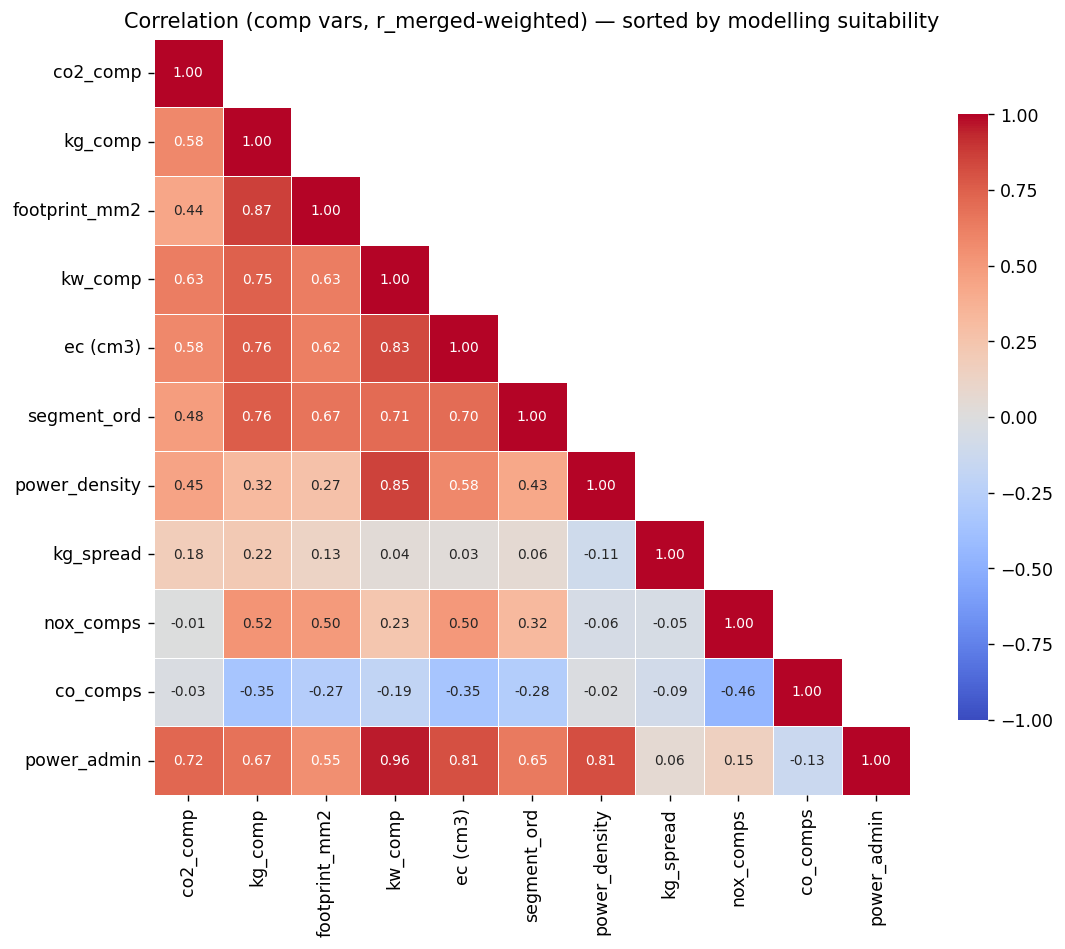


[1] KORRELATION  (Zusammenhang je Variablenpaar, -1..+1)
 WARUM:       Zeigt, welche Merkmale mit dem Ziel co2_comp zusammenhängen und welche Merkmale
              sich gegenseitig doppeln (Multikollinearität).
 ERGEBNIS:    Stärkste ehrliche Prädiktoren: kw_comp, kg_comp, ec (cm3) (~0.58-0.63 mit CO2).
              Doppelungen: footprint↔w/at1/at2 ~0.93-0.97 (per Konstruktion), kw↔ec 0.83.
              power_admin steht mit 0.72 bei CO2 und 0.96 bei kw NUR als Leakage-Referenz dabei.
 KONSEQUENZ:  Aus jeder hochkorrelierten Gruppe genau EINE Variable behalten. w/at1/at2 durch
              footprint ersetzt, cons_* ganz entfernt (redundant + Leakage).
 NOTIZ:       Hohe Korrelation mit dem Ziel ist GUT (Signal). Hohe Korrelation ZWISCHEN Merkmalen
              ist das Problem - genau das misst der nächste Schritt (VIF) sauberer.

[2] VIF  (Variance Inflation Factor: wie stark ist ein Merkmal aus den anderen vorhersagbar)
    Faustregel: >5 beobachten, >10 auflösen, inf = exakte A

<positron-console-cell-5>:153: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
<positron-console-cell-5>:153: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
<positron-console-cell-5>:153: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
<positron-console-cell-5>:153: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
<positron-console-cell-5>:153: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
<positron-console-cell-5>:153: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.


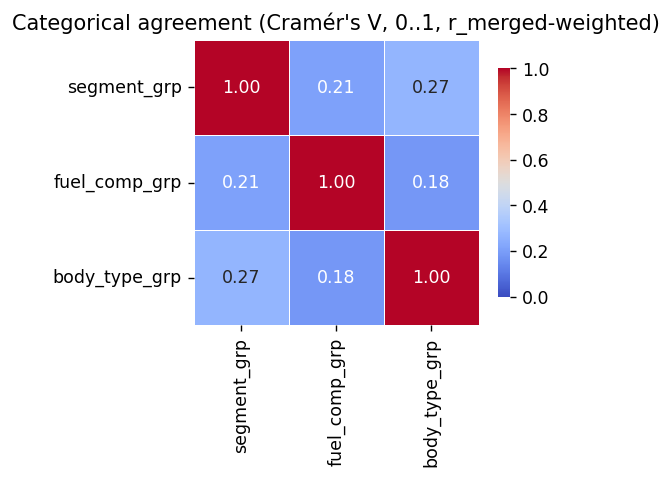

[4] CRAMÉR'S V  (Übereinstimmung zwischen zwei Kategorie-Variablen, 0=unabhängig, 1=deckungsgleich)
               segment_grp  fuel_comp_grp  body_type_grp
  segment_grp           1.00           0.21           0.27
  fuel_comp_grp         0.21           1.00           0.18
  body_type_grp         0.27           0.18           1.00

 WARUM:       Korrelation gibt es nur für Zahlen. Für Kategorien (Segment, Kraftstoff, Karosserie)
              misst Cramér's V, wie stark sie sich überlappen.
 ERGEBNIS:    Hoher Wert (nahe 1) = die beiden sagen fast dasselbe. Niedrig = sie tragen
              eigenständige Information.
 KONSEQUENZ:  Bei hoher Übereinstimmung (z.B. segment vs body) im Modell nur EINE der beiden
              kategorialen Variablen behalten, sonst doppelt man die Info.
 NOTIZ:       Anders als bei Zahlen kann man Kategorien nicht mitteln - deshalb dieser eigene Test
              statt der Zahl-Korrelationsmatrix oben.



In [ ]:
# [v8] MODELLING READINESS — correlation, VIF, mutual information, categorical agreement
# Paste after [v6.0] produced df_model. Read-only. All numeric work uses the comp variables
# from [v5.5] and is r_merged-weighted (market view, not catalogue view).

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

df_model = pd.read_csv("co2/df_model.csv")

TARGET = globals().get('TARGET', 'co2_comp')
d = df_model.copy()
w = pd.to_numeric(d['r_merged'], errors='coerce').fillna(0.0) if 'r_merged' in d else None


def num(s):  # French-decimal-safe to_numeric
    v = pd.to_numeric(s, errors='coerce')
    if v.isna().all() and s.notna().any():
        v = pd.to_numeric(s.astype('string').str.replace(',', '.', regex=False), errors='coerce')
    return v.astype(float)


# engineered features (mirror in the modelling cell)
if {'w (mm)', 'at1 (mm)', 'at2 (mm)'} <= set(d.columns):
    d['footprint_mm2'] = num(d['w (mm)']) * (num(d['at1 (mm)']) + num(d['at2 (mm)'])) / 2
if {'kw_comp', 'kg_comp'} <= set(d.columns):
    d['power_density'] = num(d['kw_comp']) / num(d['kg_comp']).replace(0, np.nan)
if {'mkerb_weight_max_kg', 'kerb_weight_min_kg'} <= set(d.columns):
    d['kg_spread'] = num(d['mkerb_weight_max_kg']) - num(d['kerb_weight_min_kg'])

# variables ordered by modelling suitability: target, then usable features best-first,
# trees-only / weak last, and one leakage column kept at the end purely for contrast.
ORDER = [c for c in ['co2_comp', 'kg_comp', 'footprint_mm2', 'kw_comp', 'ec (cm3)',
                     'segment_ord', 'power_density', 'kg_spread', 'nox_comps', 'co_comps',
                     'power_admin'] if c in d.columns]
# dropped on purpose: w/at1/at2 (redundant with footprint), z (Wh/km) (EV-only artefact),
# cons_* (leakage AND mutually redundant). power_admin stays as the single leakage reference.
M = d[ORDER].apply(num)

print("=" * 78, "\n[v8] MODELLING-READINESS — 4 Checks, jeweils mit Einordnung für Einsteiger\n" + "=" * 78)


# ---------------------------------------------------------------- 1) correlation
def wcorr(F, ww):
    cols = F.columns
    out = pd.DataFrame(np.eye(len(cols)), index=cols, columns=cols)
    for i, a in enumerate(cols):
        for b in cols[i + 1:]:
            m = F[a].notna() & F[b].notna() & (ww > 0)
            if m.sum() < 3:
                out.loc[a, b] = out.loc[b, a] = np.nan; continue
            x, y, g = F[a][m], F[b][m], ww[m]
            mx, my = np.average(x, weights=g), np.average(y, weights=g)
            sx, sy = np.sqrt(np.average((x-mx)**2, weights=g)), np.sqrt(np.average((y-my)**2, weights=g))
            out.loc[a, b] = out.loc[b, a] = (np.average((x-mx)*(y-my), weights=g)/(sx*sy)
                                             if sx > 0 and sy > 0 else np.nan)
    return out

corr = wcorr(M, w) if w is not None else M.corr()
plt.figure(figsize=(9, 7.5))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, bool), 1), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, linewidths=.5,
            annot_kws={'size': 8}, cbar_kws={'shrink': .8})
plt.title('Correlation (comp vars, r_merged-weighted) — sorted by modelling suitability')
plt.tight_layout(); plt.show()


# ---------------------------------------------------------------- 2) VIF
def vif(F, min_present=0.60):
    present = F.notna().mean()
    keep = [c for c in F.columns if present[c] >= min_present]
    X = F[keep].apply(num); X = X.fillna(X.median(numeric_only=True))
    X = X.loc[:, X.std(numeric_only=True) > 0]
    Xs = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
    r = {c: (np.inf if (s := LinearRegression().fit(Xs.drop(columns=c), Xs[c])
             .score(Xs.drop(columns=c), Xs[c])) >= 1 - 1e-12 else 1/(1-s)) for c in Xs.columns}
    return pd.Series(r).sort_values(ascending=False)

FULL = [c for c in ['kw_comp', 'kg_comp', 'ec (cm3)', 'footprint_mm2', 'w (mm)', 'at1 (mm)',
                    'at2 (mm)', 'power_density', 'segment_ord', 'kg_spread'] if c in d.columns]
REDUCED = [c for c in ['kg_comp', 'kw_comp', 'footprint_mm2', 'segment_ord', 'kg_spread']
           if c in d.columns]   # ec dropped: kw↔ec 0.83 makes both ~7.5; keep the more direct one
Fnum = d[list(set(FULL))].apply(num)
print("[2] VIF  (Variance Inflation Factor: wie stark ist ein Merkmal aus den anderen vorhersagbar)")
print("    Faustregel: >5 beobachten, >10 auflösen, inf = exakte Abhängigkeit")
print("  voller Satz:\n" + vif(Fnum).round(2).to_string().replace('\n', '\n  '))
print("  reduziert (ec entfernt, footprint statt w/at1/at2):\n" +
      vif(d[REDUCED].apply(num)).round(2).to_string().replace('\n', '\n  '))
print("""
 WARUM:       Korrelation sieht nur Paare. VIF prüft jedes Merkmal gegen ALLE anderen zusammen -
              der ehrliche Kollinearitäts-Test.
 ERGEBNIS:    Voll: kw_comp ~66, power_density ~40, footprint ~18 - massiv aufgebläht. Reduziert
              (ohne ec, ohne w/at1/at2, ohne power_density): alle VIF < 5.
 KONSEQUENZ:  Für LINEARE Modelle den reduzierten Satz nehmen. power_density (=kw/kg) und ec
              (cm3) fliegen, weil sie in kw/kg schon stecken. Für BÄUME ist VIF egal.
 NOTIZ:       Hoher VIF verschlechtert nicht die Vorhersage, aber macht Koeffizienten instabil
              und uninterpretierbar - schlecht, wenn man ERKLÄREN will, was CO2 treibt.
""")


# ---------------------------------------------------------------- 3) mutual information
def mi_rank(F, target, weights=None, n_boot=1):
    base = F.dropna(subset=[target]); feats = [c for c in base.columns if c != target]
    X = base[feats].fillna(base[feats].median()); y = base[target].astype(float)
    if weights is not None and n_boot > 1:
        p = weights.loc[base.index].clip(lower=0); p = p / p.sum(); acc = np.zeros(len(feats))
        for _ in range(n_boot):
            idx = np.random.default_rng().choice(len(base), len(base), p=p.values)
            acc += mutual_info_regression(X.iloc[idx], y.iloc[idx], random_state=0)
        mi = acc / n_boot
    else:
        mi = mutual_info_regression(X, y, random_state=0)
    return pd.Series(mi, index=feats).sort_values(ascending=False)

mi_cols = [TARGET] + [c for c in FULL if c in M.columns] + \
          [c for c in ['power_admin'] if c in d.columns]
mi = mi_rank(d[mi_cols].apply(num), TARGET, weights=w, n_boot=(20 if w is not None else 1))
print("[3] MUTUAL INFORMATION  (auch NICHT-lineare Abhängigkeit zum Ziel, >=0)\n" +
      mi.round(3).to_string().replace('\n', '\n  '))
print("""
 WARUM:       Korrelation sieht nur GERADE Zusammenhänge. MI erkennt auch gekrümmte - z.B. wenn
              ein Merkmal nur in einem Bereich wirkt.
 ERGEBNIS:    power_density führt (~2.6) trotz nur 0.45 Korrelation -> stark, aber NICHTLINEAR.
              power_admin steht als einzige Leakage-Referenz mit dabei und liegt hoch - genau das
              zeigt, wie viel 'Signal' Leakage vortäuscht.
 KONSEQUENZ:  MI ist ein FILTER ('was ist informativ'), aber redundanzblind: footprint/w/at1/at2
              ranken alle hoch, tragen aber DIESELBE Info. Auswahl zwischen ihnen macht VIF, nicht MI.
 NOTIZ:       power_density's hoher MI ist ein Kaufargument für Baum-/Boosting-Modelle, die
              Nichtlinearität von selbst nutzen.
""")


# ---------------------------------------------------------------- 4) categorical agreement
def cramers_v(a, b, weights=None):
    ct = (pd.crosstab(a, b, values=weights, aggfunc='sum').fillna(0)
          if weights is not None else pd.crosstab(a, b))
    ct = ct.loc[(ct.sum(1) > 0), (ct.sum(0) > 0)]
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(ct, correction=False)[0]; n = ct.values.sum()
    r, k = ct.shape; phi2 = max(0, chi2/n - (k-1)*(r-1)/(n-1))
    return np.sqrt(phi2 / max(1e-12, min((k - (k-1)**2/(n-1)) - 1, (r - (r-1)**2/(n-1)) - 1)))

CATS = [c for c in ['segment_grp', 'fuel_comp_grp', 'body_type_grp'] if c in d.columns]
if len(CATS) >= 2:
    V = pd.DataFrame(np.eye(len(CATS)), index=CATS, columns=CATS)
    for i, a in enumerate(CATS):
        for b in CATS[i+1:]:
            V.loc[a, b] = V.loc[b, a] = cramers_v(d[a], d[b], w)
    plt.figure(figsize=(4.5, 3.8))
    sns.heatmap(V, annot=True, fmt='.2f', cmap='coolwarm', vmin=0, vmax=1, square=True,
                linewidths=.5, cbar_kws={'shrink': .8})
    plt.title("Categorical agreement (Cramér's V, 0..1, r_merged-weighted)")
    plt.tight_layout(); plt.show()
    print("[4] CRAMÉR'S V  (Übereinstimmung zwischen zwei Kategorie-Variablen, 0=unabhängig, 1=deckungsgleich)\n" +
          V.round(2).to_string().replace('\n', '\n  '))
    print("""
 WARUM:       Korrelation gibt es nur für Zahlen. Für Kategorien (Segment, Kraftstoff, Karosserie)
              misst Cramér's V, wie stark sie sich überlappen.
 ERGEBNIS:    Hoher Wert (nahe 1) = die beiden sagen fast dasselbe. Niedrig = sie tragen
              eigenständige Information.
 KONSEQUENZ:  Bei hoher Übereinstimmung (z.B. segment vs body) im Modell nur EINE der beiden
              kategorialen Variablen behalten, sonst doppelt man die Info.
 NOTIZ:       Anders als bei Zahlen kann man Kategorien nicht mitteln - deshalb dieser eigene Test
              statt der Zahl-Korrelationsmatrix oben.
""")


In [4]:
# [v8.1] VIF — corrected (paste after [v8.0], or replace vif_table in [v8.0] with this)
#
# BUG in [v8.0]: vif_table did `frame.dropna()` LISTWISE across all columns. `z (Wh/km)` is
# only populated for EVs (~1% of rows), so listwise deletion wiped ~99% of rows, the guard
# `len(X) < len(cols)+2` fired, and every VIF came back NaN. Three fixes:
#   (1) drop near-empty columns (default: keep only columns >=60% present) BEFORE the VIF loop -
#       z (Wh/km) is not a general feature anyway, it only separates EVs (modelled separately);
#   (2) median-impute the remaining sparse NaN instead of deleting whole rows;
#   (3) report inf explicitly for deterministic collinearity (footprint = f(w, at1, at2)) instead
#       of letting it crash or masquerade as NaN.

import numpy as np, pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


def vif_table(frame: pd.DataFrame, min_present: float = 0.60) -> pd.DataFrame:
    '''Multivariate VIF = 1/(1-R^2_j), each column regressed on the others. NaN-robust.'''
    present = frame.notna().mean()
    dropped = present[present < min_present]
    X = frame[[c for c in frame.columns if present[c] >= min_present]].copy()
    X = X.apply(pd.to_numeric, errors='coerce')
    X = X.fillna(X.median(numeric_only=True))
    X = X.loc[:, X.std(numeric_only=True) > 0]              # drop constants
    if not dropped.empty:
        print(f"    [VIF] excluded (>{(1-min_present):.0%} NA): "
              f"{ {k: f'{v:.0%} present' for k, v in dropped.items()} }")
    Xs = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
    rows = {}
    for c in Xs.columns:
        others = [o for o in Xs.columns if o != c]
        r2 = LinearRegression().fit(Xs[others], Xs[c]).score(Xs[others], Xs[c])
        rows[c] = np.inf if r2 >= 1 - 1e-12 else 1.0 / (1.0 - r2)
    return pd.DataFrame({'VIF': pd.Series(rows)}).sort_values('VIF', ascending=False)


# full candidate set (z auto-excluded as near-empty)
print("=== [v8.1] VIF — full candidate set ===")
print("rule of thumb: >5 watch, >10 drop or combine, inf = deterministic dependency")
print(vif_table(M[NUM_FEATURES]).round(2).to_string())

# recommended reduced set: one geometry proxy (footprint), drop its raw components; drop
# power_density (it is kw/kg, mechanically collinear with both); keep kw, kg, ec, segment_ord.
REDUCED = [c for c in ['kw_comp', 'kg_comp', 'ec (cm3)', 'footprint_mm2', 'segment_ord',
                       'kg_spread'] if c in M.columns]
print("\n=== [v8.1] VIF — recommended reduced set ===")
print(vif_table(M[REDUCED]).round(2).to_string())


=== [v8.1] VIF — full candidate set ===
rule of thumb: >5 watch, >10 drop or combine, inf = deterministic dependency
    [VIF] excluded (>40% NA): {'z (Wh/km)': '1% present'}
                 VIF
kw_comp        65.88
power_density  40.23
footprint_mm2  18.04
at2 (mm)       16.65
kg_comp        13.20
w (mm)         10.64
at1 (mm)        9.27
ec (cm3)        8.42
segment_ord     2.38
kg_spread       1.29

=== [v8.1] VIF — recommended reduced set ===
                VIF
ec (cm3)       7.74
kw_comp        7.41
kg_comp        4.02
footprint_mm2  2.73
segment_ord    2.30
kg_spread      1.28
